In [10]:
import pandas as pd

# Data Sources and File Structure

This project analyzes movie performance across the period **2000–2025**, combining financial data from TMDB with descriptive data from IMDb.

The IMDb datasets provide structured information about movies, ratings, and individuals involved in film production, while the TMDB dataset supplies financial variables such as budget and revenue.

---

## IMDb Datasets

### name.basics.tsv

This dataset contains biographical and professional information about individuals in the film industry, including actors, directors, writers, and other contributors.

Key columns:

- **nconst** – unique IMDb identifier for a person  
- **primaryName** – person's name  
- **birthYear / deathYear** – lifespan information  
- **primaryProfession** – main professions (can include multiple roles)  
- **knownForTitles** – IMDb IDs of notable works  


---

### title.principals.tsv

This dataset links movies to the people involved in them.

Each row represents a relationship between a movie and a person, along with their role.

Key columns:

- **tconst** – movie identifier  
- **nconst** – person identifier  
- **category** – role (actor, director, etc.)  
- **job** – detailed role description (if available)  
- **characters** – character names (for actors)  


---

### title.basics.tsv

This dataset contains general metadata about movies.

Key information includes:

- title type  
- release year  
- runtime  
- genres  


---

### title.ratings.tsv

This dataset provides audience reception metrics.

Key columns:

- **averageRating** – average IMDb rating  
- **numVotes** – number of votes  


---

## TMDB Dataset

### movies_budget.csv

This dataset contains financial information about movies and serves as the starting point for the entire analysis.

The dataset was collected using the TMDB API, focusing specifically on movies released between **2000 and 2025**, which defines the time scope of this project.


Key columns:

- **imdb_id** – IMDb identifier used to match with IMDb datasets  
- **budget** – movie production budget  
- **revenue** – worldwide box office revenue  
- **year** – release year  

This dataset plays a central role in the analysis:

- it defines the **set of movies included in the project**  
- it provides the **financial variables** used to compute performance metrics (profit, ROI, success)  
- it serves as the **reference dataset** used to filter all IMDb datasets  

Since IMDb datasets contain the entire catalog of movies and individuals, we use the `imdb_id` values from this dataset to retain only the relevant subset of:

- movie metadata  
- ratings  
- cast and crew  
- individuals (actors and directors)  

In [ ]:
# Define File Path
"""
names_path = 'CapstoneProject/name.basics.tsv'
titles_path = 'CapstoneProject/title.basics.tsv'
principals_path = 'CapstoneProject/title.principals.tsv'
ratings_path = 'CapstoneProject/title.ratings.tsv'
budget_path = 'CapstoneProject/movies_budget.csv'
"""

# Data Loading and Initial Filtering




### Load Movie Financial Data

In [ ]:
movie_budget = pd.read_csv(budget_path)

### Load Individuals Dataset

In [ ]:
movie_people = pd.read_csv(names_path, sep="\t")

### Filter the IMDb Principals Dataset

The title.principals dataset is very large (~4GB), so it cannot be loaded entirely into memory.  
Instead, we filter it efficiently using chunk processing to retain only rows corresponding to movies in the **movie budget dataset**.  

In [ ]:
imdb_ids = set(movie_budget["imdb_id"])
chunksize = 100000
filtered_chunks = []

for chunk in pd.read_csv(principals_path, sep="\t", chunksize=chunksize):
    filtered = chunk[chunk["tconst"].isin(imdb_ids)]
    if not filtered.empty:
        filtered_chunks.append(filtered)

movie_principals = pd.concat(filtered_chunks)
# movie_principals.to_csv('movie_principals.csv', index=False)


### Filter the Individuals Dataset

We retain only individuals who appear in the `movie_principals` dataset.

In [ ]:
principal_ids = set(movie_principals["nconst"])

movie_people_filtered = movie_people[
    movie_people["nconst"].isin(principal_ids)
].reset_index(drop=True)

# movie_people_filtered.to_csv('movie_people.csv')

### Load and Filter Ratings Dataset

We filter ratings to include only movies from our dataset.

In [ ]:
movie_ratings = pd.read_csv(ratings_path, sep="\t")

movie_ratings = movie_ratings[
    movie_ratings["tconst"].isin(imdb_ids)
]

# movie_ratings.to_csv('movie_ratings.csv')

### Load and Filter Movie Metadata

We filter this dataset to keep only the movies in our budget dataset.

In [ ]:
movie_titles = pd.read_csv(titles_path, sep="\t")

movie_titles = movie_titles[
    movie_titles["tconst"].isin(imdb_ids)
]

# movie_titles.to_csv('movie_titles.csv')

### **With the data preparation and filtering steps completed, we now proceed to exploratory data analysis.**


## **Exploratory Data Analysis**

This part presents an exploratory analysis of movie performance using financial and audience-related metrics.

We investigate how different factors such as genre, budget, and cast affect both financial success (measured by ROI) and audience reception (measured by ratings).

The analysis is structured into several key sections:

- Data preparation and feature engineering
- Genre analysis (individual genres and combinations)
- Temporal trends in genre performance
- Actor-level analysis and star power
- Clustering of actors and movies to identify archetypes

The goal is to uncover patterns in the film industry and understand the trade-offs between profitability, popularity, and perceived quality.

In [5]:
!git clone https://github.com/psklam/Team-27-SIADS-699.git

Cloning into 'Team-27-SIADS-699'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 28 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 6.78 MiB | 3.88 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [6]:
%cd Team-27-SIADS-699

/content/Team-27-SIADS-699


In [7]:
!ls


Film_Financial_Success_Modelling.ipynb	movie_ratings.csv  README.md
movie_people.csv			movies_budget.csv  Requirements.txt
movie_principals.csv			movie_titles.csv


### Data Loading

In [8]:
# Financial Data

budget_path = 'movies_budget.csv'

In [11]:
movie_budget = pd.read_csv(budget_path)

In [12]:
# This dataset contains budget and revenue information for each movie

movie_budget.head(5)

,imdb_id,budget,revenue,year
0,tt0120755,125000000,546388108,2000
1,tt0172495,103000000,465516248,2000
2,tt0162222,90000000,429632142,2000
3,tt0207201,70000000,374100000,2000
4,tt0130623,127500000,354248063,2000


In [13]:
# Load principals dataset (cast and crew: actors, directors, etc.)
movie_principals = pd.read_csv('movie_principals.csv')

In [16]:
# Standardize acting roles by merging "actress" into "actor"

movie_principals["category"] = movie_principals["category"].replace({
    "actress": "actor"
})

In [17]:
movie_principals.head()

,tconst,ordering,nconst,category,job,characters
0,tt0035423,1,nm0000212,actor,\N,"[""Kate McKay""]"
1,tt0035423,2,nm0413168,actor,\N,"[""Leopold""]"
2,tt0035423,3,nm0000630,actor,\N,"[""Stuart Besser""]"
3,tt0035423,4,nm0005227,actor,\N,"[""Charlie McKay""]"
4,tt0035423,5,nm0005169,actor,\N,"[""Darci""]"


In [18]:
# Load people metadata (names and professions of cast & crew)

movie_people_filtered = pd.read_csv('movie_people.csv')

In [19]:
movie_people_filtered.head()

,Unnamed: 0,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,0,nm0000002,Lauren Bacall,1924,2014,"actress,miscellaneous,soundtrack","tt0037382,tt0075213,tt0038355,tt0117057"
1,1,nm0000008,Marlon Brando,1924,2004,"actor,director,writer","tt0078788,tt0068646,tt0047296,tt0070849"
2,2,nm0000010,James Cagney,1899,1986,"actor,director,producer","tt0029870,tt0031867,tt0042041,tt0034236"
3,3,nm0000025,Jerry Goldsmith,1929,2004,"music_department,composer,miscellaneous","tt0119488,tt0077269,tt0117731,tt0112715"
4,4,nm0000032,Charlton Heston,1923,2008,"actor,director,writer","tt0052618,tt0049833,tt0067525,tt0052311"


In [20]:
# Load audience ratings data (ratings and vote counts)

movie_ratings = pd.read_csv('movie_ratings.csv')

In [12]:
movie_ratings.head(5)

,Unnamed: 0,tconst,averageRating,numVotes
0,18899,tt0035423,6.4,93476
1,85855,tt0113026,5.7,1488
2,90368,tt0118589,2.5,24468
3,90451,tt0118694,8.0,186162
4,91983,tt0120467,5.2,4414


In [21]:
# Load movie metadata (titles, genres, runtime, etc.)

movie_titles = pd.read_csv('movie_titles.csv', index_col=0).reset_index(drop=True)

In [22]:
# Filter out not movies
movie_titles = movie_titles[movie_titles["titleType"] == "movie"]

In [23]:
movie_titles.head(5)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0035423,movie,Kate & Leopold,Kate & Leopold,0,2001,\N,118,"Comedy,Fantasy,Romance"
1,tt0113026,movie,The Fantasticks,The Fantasticks,0,2000,\N,86,"Musical,Romance"
2,tt0118589,movie,Glitter,Glitter,0,2001,\N,104,"Drama,Music,Romance"
3,tt0118694,movie,In the Mood for Love,Fa yeung nin wah,0,2000,\N,98,"Drama,Romance"
4,tt0120467,movie,Vulgar,Vulgar,0,2000,\N,87,"Crime,Drama,Thriller"


### Data Integration and Feature Engineering

In this section, we construct a unified movie-level dataset by merging financial, metadata, and audience data.

We then perform data cleaning and feature engineering to prepare the dataset for analysis. This includes:
- Removing unnecessary or redundant columns
- Handling missing and invalid values
- Standardizing variable names
- Creating key financial metrics such as profit and ROI
- Defining a binary success indicator

The resulting dataset serves as the foundation for all subsequent analysis.

In [25]:
# Merge datasets
# ---------------------------

# Merge financial data with movie metadata
movies = movie_budget.merge(
    movie_titles,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

# Merge with audience ratings
movies = movies.merge(
    movie_ratings,
    on="tconst",
    how="left"
)


# Clean and simplify dataset
# ---------------------------

# Remove unnecessary columns
movies = movies.drop(columns=["Unnamed: 0", "tconst"])

# Drop irrelevant metadata fields
movies = movies.drop(columns=[
    "originalTitle",
    "titleType",
    "isAdult",
    "startYear",
    "endYear"
])


# Data type conversion & renaming
# ---------------------------

# Convert runtime to numeric
movies["runtimeMinutes"] = pd.to_numeric(
    movies["runtimeMinutes"],
    errors="coerce"
)

# Rename columns for clarity
movies = movies.rename(columns={
    "primaryTitle": "title",
    "runtimeMinutes": "runtime",
    "averageRating": "rating"
})



# Handle missing values
# ---------------------------

# Remove rows with missing key attributes
movies = movies.dropna(subset=[
    "title",
    "genres",
    "runtime",
    "rating",
    "numVotes"
])



# Feature engineering
# ---------------------------

# Compute financial metrics
movies["profit"] = movies["revenue"] - movies["budget"]
movies["roi"] = movies["revenue"] / movies["budget"]


# Data filtering
# ---------------------------

# Remove extremely small-budget or revenue movies
movies = movies[movies["budget"] > 1000]
movies = movies[movies["revenue"] > 1000]

# Remove extreme ROI outliers (top 1%)
upper_roi = movies["roi"].quantile(0.99)
movies = movies[movies["roi"] <= upper_roi]


# Create success label
# ---------------------------

# Define success as revenue >= 2x budget
movies["success"] = (movies["revenue"] >= 2 * movies["budget"]).astype(int)


# Final cleanup
# ---------------------------

# Remove invalid genre entries
movies = movies[movies["genres"] != "\\N"]


# Inspect final dataset
movies.info()
movies.head()

<class 'pandas.core.frame.DataFrame'>
Index: 7948 entries, 0 to 8939
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   imdb_id   7948 non-null   object 
 1   budget    7948 non-null   int64  
 2   revenue   7948 non-null   int64  
 3   year      7948 non-null   int64  
 4   title     7948 non-null   object 
 5   runtime   7948 non-null   float64
 6   genres    7948 non-null   object 
 7   rating    7948 non-null   float64
 8   numVotes  7948 non-null   float64
 9   profit    7948 non-null   int64  
 10  roi       7948 non-null   float64
 11  success   7948 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 807.2+ KB


,imdb_id,budget,revenue,year,title,runtime,genres,rating,numVotes,profit,roi,success
0,tt0120755,125000000,546388108,2000,Mission: Impossible II,123.0,"Action,Adventure,Thriller",6.1,411408.0,421388108,4.371105,1
1,tt0172495,103000000,465516248,2000,Gladiator,155.0,"Action,Adventure,Drama",8.5,1830968.0,362516248,4.519575,1
2,tt0162222,90000000,429632142,2000,Cast Away,143.0,"Adventure,Drama,Romance",7.8,684256.0,339632142,4.773690,1
3,tt0207201,70000000,374100000,2000,What Women Want,127.0,"Comedy,Fantasy,Romance",6.5,237916.0,304100000,5.344286,1
4,tt0130623,127500000,354248063,2000,Dinosaur,82.0,"Adventure,Animation,Drama",6.4,72319.0,226748063,2.778416,1


### Budget vs Revenue

Examining the relationship between production budget and revenue
helps reveal the overall structure of the movie market.
Higher budgets often correspond to higher revenues.

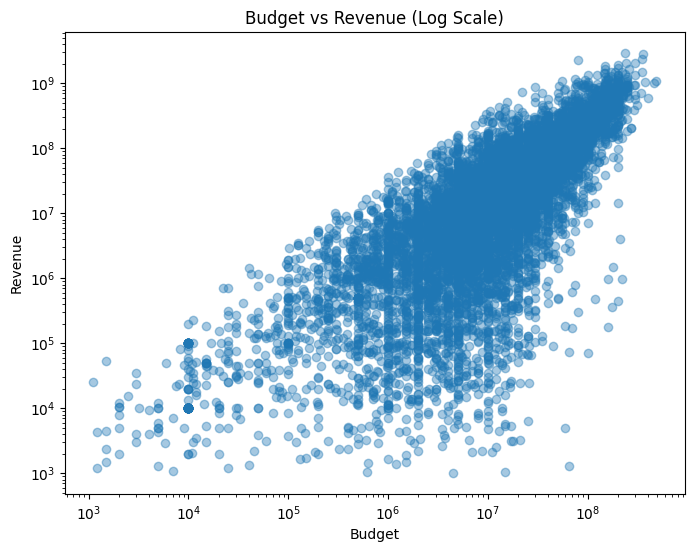

In [85]:
plt.figure(figsize=(8,6))

plt.scatter(movies["budget"], movies["revenue"], alpha=0.4)

plt.xscale("log")
plt.yscale("log")

plt.title("Budget vs Revenue (Log Scale)")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.show()

### ROI vs Budget

Although higher budgets are associated with higher revenue,
this does not necessarily imply higher profitability.

To investigate whether large productions are more financially efficient,
we examine the relationship between budget and ROI.

While higher production budgets are generally associated with higher total revenue, the relationship between budget and return on investment (ROI) is noticeably weaker.

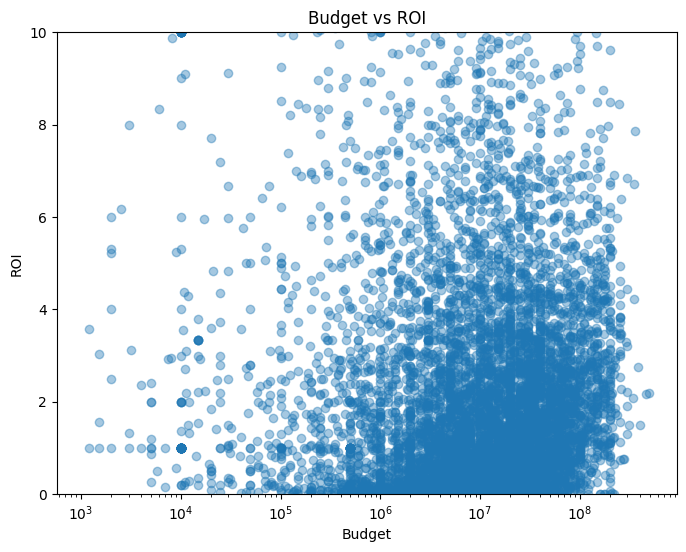

In [86]:
plt.figure(figsize=(8,6))

plt.scatter(movies["budget"], movies["roi"], alpha=0.4)

plt.xscale("log")
plt.ylim(0, 10)

plt.title("Budget vs ROI")
plt.xlabel("Budget")
plt.ylabel("ROI")

plt.show()

### Distribution of ROI

To better understand the profitability structure of the film industry, we examine the distribution of return on investment (ROI).

Most films are expected to cluster around modest returns, while a small number of films generate extremely high profitability.

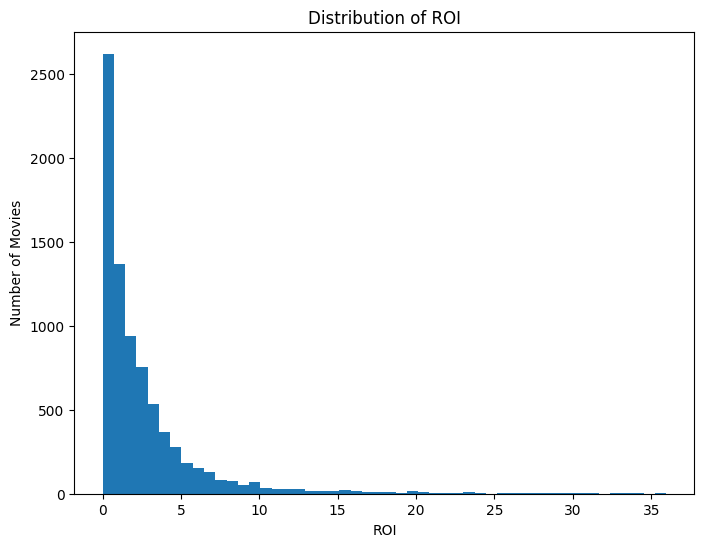

In [87]:
plt.figure(figsize=(8,6))

plt.hist(movies["roi"], bins=50)

plt.title("Distribution of ROI")
plt.xlabel("ROI")
plt.ylabel("Number of Movies")

plt.show()

### IMDb Rating vs Revenue

We examine whether movies with higher IMDb ratings tend to generate higher box office revenue.

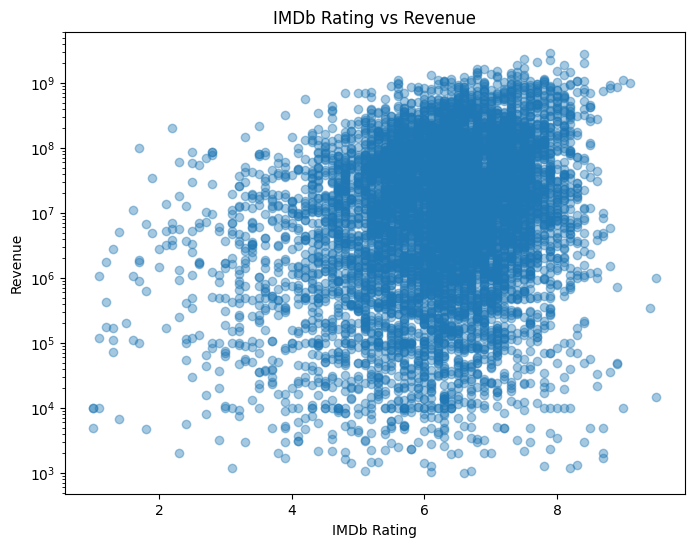

In [88]:
plt.figure(figsize=(8,6))

plt.scatter(movies["rating"], movies["revenue"], alpha=0.4)

plt.yscale("log")

plt.title("IMDb Rating vs Revenue")
plt.xlabel("IMDb Rating")
plt.ylabel("Revenue")

plt.show()

### Number of Votes vs Revenue

The number of IMDb votes may reflect audience reach and popularity.  
We examine whether movies with more votes tend to generate higher revenue.

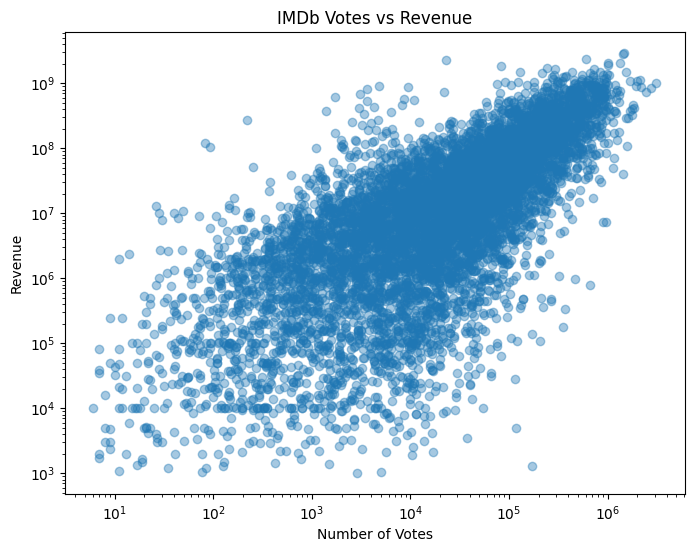

In [89]:
plt.figure(figsize=(8,6))

plt.scatter(movies["numVotes"], movies["revenue"], alpha=0.4)

plt.xscale("log")
plt.yscale("log")

plt.title("IMDb Votes vs Revenue")
plt.xlabel("Number of Votes")
plt.ylabel("Revenue")

plt.show()

### Rating vs Revenue

The scatter plot comparing IMDb ratings and movie revenue shows a positive relationship between critical reception and financial performance. While the relationship is not extremely strong, movies with higher ratings tend to generate higher revenues on average. However, the spread of points indicates that highly rated movies do not always achieve large box office returns, suggesting that additional factors such as marketing, distribution, and genre also play important roles in financial success.


### Votes vs Revenue

The relationship between the number of IMDb votes and movie revenue appears noticeably stronger. Movies that accumulate a larger number of votes generally correspond to higher box office revenue. This pattern likely reflects audience reach and popularity: films that are widely watched attract both more viewers in theaters and more users who rate them online. The upward trend in the plot suggests that audience engagement is a useful indicator of commercial performance.

## Genre Analysis

In this section, we analyze how movie genres influence both financial performance (ROI) and audience reception (ratings).

We approach this analysis in two ways:

1. **Individual Genre Analysis** – each movie contributes to all of its genres
2. **Genre Combination Analysis** – each unique genre combination is treated as a distinct category

We also incorporate a time dimension to examine how these patterns evolve across different periods.

### Individual Genre Analysis

We first analyze genres independently by allowing each movie to contribute to all of its associated genres.

This approach provides a broad view of how individual genres perform across financial and audience dimensions.

To capture temporal dynamics, we group movies into three periods:
- 2000–2010
- 2011–2020
- 2021–2025

In [26]:
# Assign time periods

def assign_period(year):
    if year <= 2010:
        return "2000–2010"
    elif year <= 2020:
        return "2011–2020"
    else:
        return "2021–2025"

movies["period"] = movies["year"].apply(assign_period)

In [27]:
# Convert genres into dummy variables

genre_dummies = movies["genres"].str.get_dummies(sep=",")
movies_split = pd.concat([movies, genre_dummies], axis=1)

genres = genre_dummies.columns

# Compute genre-level statistics

genre_stats = []

for genre in genres:
    for period in movies_split["period"].unique():
        subset = movies_split[(movies_split[genre] == 1) &
                 (movies_split["period"] == period)
                 ]



        if len(subset) >= 30:

            genre_stats.append({
                "genre": genre,
                "count": len(subset),
                "avg_roi": subset["roi"].mean(),
                "avg_rating": subset["rating"].mean(),
                "success_rate": subset["success"].mean(),
                "avg_budget": subset["budget"].mean(),
                "period": period
            })

genre_stats_df = pd.DataFrame(genre_stats)


# Example output

genre_stats_roi = genre_stats_df.sort_values("avg_roi", ascending=False)
genre_stats_rating = genre_stats_df.sort_values("avg_rating", ascending=False)
genre_stats_roi.head(10)

,genre,count,avg_roi,avg_rating,success_rate,avg_budget,period
18,Documentary,48,5.557027,6.954167,0.562500,5.947770e+06,2000–2010
33,Horror,339,4.610884,5.665487,0.486726,1.151629e+07,2011–2020
38,Musical,34,3.949454,6.670588,0.558824,1.459338e+07,2011–2020
40,Mystery,321,3.913301,6.126480,0.464174,1.355645e+07,2011–2020
19,Documentary,66,3.437948,7.118182,0.560606,2.295525e+06,2011–2020
36,Music,91,3.425417,6.464835,0.494505,1.251370e+07,2011–2020
7,Animation,241,3.408878,6.290041,0.518672,5.647610e+07,2011–2020
41,Mystery,130,3.407875,5.976923,0.423077,1.764442e+07,2021–2025
51,Thriller,517,3.407178,6.160348,0.462282,1.982268e+07,2011–2020
46,Sci-Fi,203,3.352189,6.233990,0.541872,7.040142e+07,2011–2020


In [28]:

genre_stats_rating.head(10)

,genre,count,avg_roi,avg_rating,success_rate,avg_budget,period
19,Documentary,66,3.437948,7.118182,0.560606,2.295525e+06,2011–2020
18,Documentary,48,5.557027,6.954167,0.562500,5.947770e+06,2000–2010
9,Biography,185,2.378875,6.925946,0.308108,2.346891e+07,2000–2010
10,Biography,275,2.454944,6.872364,0.370909,1.978931e+07,2011–2020
11,Biography,95,2.019938,6.863158,0.242105,2.766065e+07,2021–2025
53,War,54,1.486261,6.859259,0.259259,2.589396e+07,2000–2010
29,History,102,1.917662,6.792157,0.254902,2.383627e+07,2000–2010
30,History,168,1.944132,6.720238,0.303571,2.016589e+07,2011–2020
49,Sport,54,1.801153,6.698148,0.333333,1.609724e+07,2011–2020
31,History,73,2.108037,6.679452,0.219178,2.947698e+07,2021–2025


We rank genres based on two key metrics:

- **ROI (financial efficiency)**
- **Rating (audience perception)**

The following visualizations show the top-performing genres for each metric.

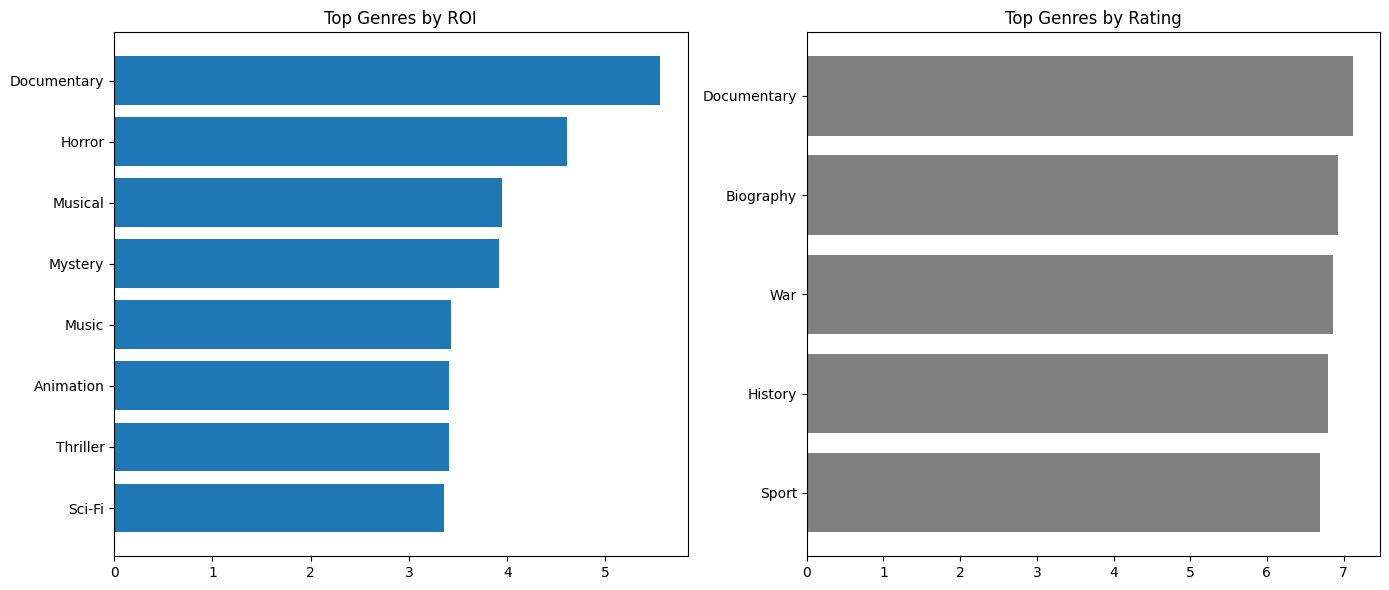

In [29]:
import matplotlib.pyplot as plt

top_genres_roi = genre_stats_roi.head(10)
top_genres_rating = genre_stats_rating.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ROI plot (blue)
axes[0].barh(
    top_genres_roi["genre"],
    top_genres_roi["avg_roi"]
)
axes[0].set_title("Top Genres by ROI")
axes[0].invert_yaxis()

# Rating plot (pale purple)
axes[1].barh(
    top_genres_rating["genre"],
    top_genres_rating["avg_rating"],
    color="gray"
)
axes[1].set_title("Top Genres by Rating")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Individual Genre Analysis

We first analyzed genres independently by allowing each movie to contribute to all of its associated genres. This provides a broad, aggregated view of how each genre performs across the dataset.

#### Financial Performance (ROI)

Documentary films achieve the highest average ROI, reaching approximately **5.56 in 2000–2010** and **3.44 in 2011 – 2020**, while operating with very low average budgets (approximately **2 – 6M USD**). This indicates that their financial success is primarily driven by cost efficiency rather than large revenues.

Horror and Mystery also demonstrate strong ROI performance. Horror reaches an average ROI of approximately **4.61**, while Mystery ranges between **3.4 and 3.9**, with relatively modest budgets (approximately **11M – 19M USD**) and consistent success rates (around **42% – 48%**). These genres follow a low-cost, high-return production model.

In contrast, higher-budget genres such as Animation (average budget ~ 56M USD) and Sci-Fi (~ 70M USD) still achieve solid ROI (around **3.3 – 3.4**), but their efficiency is lower relative to low-budget genres. This suggests diminishing returns as production costs increase.

#### Audience Ratings

When ranked by rating, the top genres shift significantly. Documentary remains highly rated (approximately **7.0 – 7.1**), but Biography, War, and History emerge as the highest-rated genres overall, with ratings consistently around **6.7–6.9**.

However, these genres exhibit lower ROI (approximately **1.5 – 2.4**) and lower success rates (around **24% – 37%**), indicating that strong audience reception does not necessarily translate into financial efficiency.

#### Key Insight

At the individual genre level, financial efficiency and audience perception are not aligned:

- **High ROI → low-budget genres** (Documentary, Horror)
- **High ratings → narrative-driven genres** (Biography, War, History)


### Genre Combination Analysis

We now analyze genre combinations by treating each unique genre mix as a separate category.

Unlike the previous approach, where genres are evaluated independently, this method captures interactions between genres and how they jointly influence performance.

In [31]:
# Treat full genre string as category

movies_combo = movies.copy()

combo_stats = movies_combo.groupby(["genres", "period"]).agg(
    count=("title", "count"),
    avg_roi=("roi", "mean"),
    avg_rating=("rating", "mean"),
    success_rate=("success", "mean")
).reset_index()

# Filter small groups

combo_stats = combo_stats[combo_stats["count"] >= 20]

# Top combinations

combo_stats_roi = combo_stats.sort_values("avg_roi", ascending=False)
combo_stats_rating = combo_stats.sort_values("avg_rating", ascending=False)
combo_stats_roi.head(10)

,genres,period,count,avg_roi,avg_rating,success_rate
841,"Horror,Mystery,Thriller",2011–2020,51,9.298563,5.625490,0.745098
842,"Horror,Mystery,Thriller",2021–2025,35,6.477119,5.577143,0.714286
722,"Drama,Horror,Mystery",2000–2010,22,4.872622,5.890909,0.590909
7,"Action,Adventure,Animation",2011–2020,58,4.450726,6.701724,0.586207
478,"Comedy,Drama,Music",2011–2020,24,4.344003,6.650000,0.583333
8,"Action,Adventure,Animation",2021–2025,26,4.175967,6.842308,0.538462
242,"Adventure,Comedy,Drama",2011–2020,27,4.153511,6.900000,0.666667
440,"Comedy,Crime,Drama",2011–2020,26,4.050028,6.450000,0.500000
840,"Horror,Mystery,Thriller",2000–2010,42,3.950053,5.595238,0.428571
568,"Comedy,Romance",2011–2020,80,3.884546,5.928750,0.675000


In [32]:
combo_stats_rating.head(10)

,genres,period,count,avg_roi,avg_rating,success_rate
641,Documentary,2011–2020,36,3.713008,7.386111,0.500000
385,"Biography,Comedy,Drama",2011–2020,24,3.774335,7.062500,0.666667
589,"Crime,Drama",2000–2010,40,2.765098,7.012500,0.375000
411,"Biography,Drama,History",2021–2025,30,2.493669,6.923333,0.200000
242,"Adventure,Comedy,Drama",2011–2020,27,4.153511,6.900000,0.666667
409,"Biography,Drama,History",2000–2010,34,3.095011,6.891176,0.411765
410,"Biography,Drama,History",2011–2020,55,1.861230,6.887273,0.272727
388,"Biography,Crime,Drama",2000–2010,26,1.673878,6.884615,0.307692
8,"Action,Adventure,Animation",2021–2025,26,4.175967,6.842308,0.538462
590,"Crime,Drama",2011–2020,22,1.796014,6.795455,0.272727


The following plots highlight the top-performing genre combinations in terms of ROI and ratings.

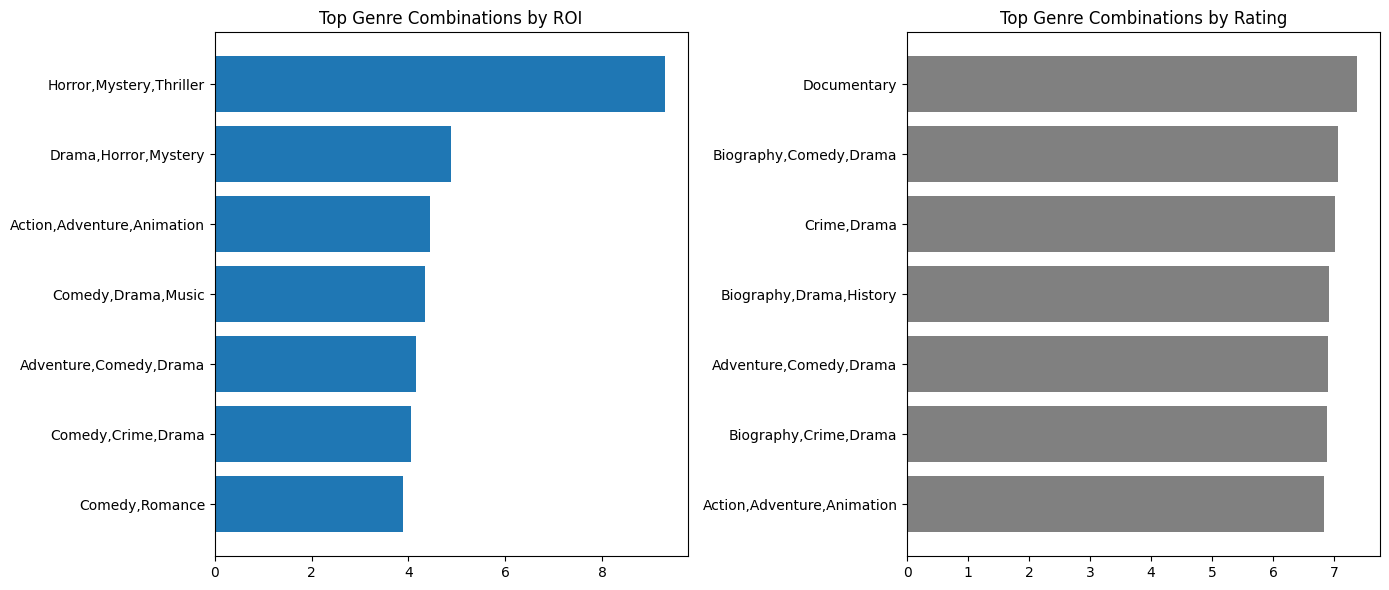

In [33]:
top_combos_roi = combo_stats_roi.head(10)
top_combos_rating = combo_stats_rating.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ROI
axes[0].barh(
    top_combos_roi["genres"],
    top_combos_roi["avg_roi"]
)
axes[0].set_title("Top Genre Combinations by ROI")
axes[0].invert_yaxis()

# Rating (grey)
axes[1].barh(
    top_combos_rating["genres"],
    top_combos_rating["avg_rating"],
    color="gray"
)
axes[1].set_title("Top Genre Combinations by Rating")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Genre Combination Analysis

We next analyzed genre combinations by treating each unique genre mix as a separate category. This allows us to capture interaction effects between genres that are not visible in the individual genre analysis.

#### Financial Performance (ROI)

The highest ROI combinations are heavily concentrated around similar genre groupings, particularly those involving Horror, Mystery, and Thriller.

The combination **Horror–Mystery–Thriller** consistently dominates across all periods, achieving an average ROI of approximately:
- **9.30 (2011–2020)**
- **6.48 (2021–2025)**
- **3.95 (2000–2010)**

Other high-performing combinations within this family include **Drama–Horror–Mystery** (ROI ~4.87), reinforcing the strength of suspense-driven genres.

Rather than indicating multiple distinct high-performing combinations, these results suggest that a specific family of genres consistently produces strong financial returns.

This pattern likely reflects a shared production model: relatively low budgets combined with strong audience demand, leading to high financial efficiency.

Other combinations, such as **Action–Adventure–Animation**, also perform well (ROI ~4.2–4.5), but do not reach the same level of profitability as the Horror-based group.

#### Audience Ratings

A similar concentration appears when analyzing ratings, but within a different genre family.

The highest-rated combinations are dominated by Documentary and Drama-based mixes:
- **Documentary (~7.39)**
- **Biography–Comedy–Drama (~7.06)**
- **Crime–Drama (~7.01)**
- **Biography–Drama–History (~6.89–6.92 across periods)**

These combinations consistently achieve strong audience ratings but show lower ROI compared to the top-performing financial combinations.

#### Key Insight

Unlike the individual genre analysis, the combination analysis does not reveal many distinct high-performing categories. Instead, it highlights that:

- Financial performance is concentrated within a small group of closely related genres (Horror/Mystery/Thriller)
- Audience ratings are concentrated within a different group (Documentary and Drama-based combinations)

This suggests that genre interactions reinforce existing patterns rather than creating entirely new ones.

### Final Synthesis

Combining both analytical approaches provides a more complete and nuanced understanding of movie performance.

The individual genre analysis reveals broad structural patterns in the industry. Low-budget genres such as Documentary and Horror tend to achieve the highest ROI, driven by cost efficiency, while genres such as Biography, War, and History consistently achieve higher audience ratings but lower financial efficiency. This highlights a clear separation between financial success and perceived quality.

The genre combination analysis reinforces these findings rather than introducing entirely new patterns. Instead of revealing a wide variety of high-performing combinations, the results are concentrated within a small number of genre families:

- **Suspense-driven genres** (Horror, Mystery, Thriller) dominate financial performance  
- **Narrative-driven genres** (Biography, Drama) dominate audience ratings  

This indicates that genre interactions primarily amplify the characteristics of these underlying genre groups rather than creating fundamentally new dynamics.

#### Key Conclusions

- Financial success and audience ratings represent distinct dimensions of performance  
- Low-budget genres achieve higher ROI due to cost efficiency  
- High-rated genres prioritize storytelling and critical reception over profitability  
- Genre combinations reinforce existing genre patterns rather than introducing diverse outcomes  
- Movie performance is concentrated within a small number of dominant genre families  

### Genre Trends Over Time

We extend our analysis by introducing a time dimension, grouping movies into periods based on release year. This allows us to examine how genre performance evolves across different eras.

Using the same two approaches as before - individual genres and genre combinations we analyze changes in ROI, ratings, and success rates over time, identifying whether key patterns remain stable or shift across periods.

### Individual Genres Over Time

We evaluate how individual genres perform across time periods. Each movie contributes to all of its associated genres, allowing us to track broad trends in ROI and ratings.

In [34]:
# Extract unique time periods

periods = movies_split.period.unique().tolist()

In [35]:
# Store all results across periods

all_genre_tables = []

for period in periods:

    # Filter dataset for current period
    subset = movies_split[movies_split["period"] == period]

    genre_stats = []

    for genre in genres:
        g = subset[subset[genre] == 1]

        # Ensure statistical reliability (minimum sample size)
        if len(g) >= 30:
            genre_stats.append({
                "genre": genre,
                "avg_roi": g["roi"].mean(),
                "avg_rating": g["rating"].mean()
            })
    # Convert to DataFrame
    df = pd.DataFrame(genre_stats)

    # top ROI
    top_roi = df.sort_values("avg_roi", ascending=False).head(10).reset_index(drop=True)
    top_roi["rank"] = top_roi.index + 1
    top_roi["type"] = "ROI"
    top_roi["period"] = period
    top_roi = top_roi.rename(columns={"avg_roi": "value"})

    # top Rating
    top_rating = df.sort_values("avg_rating", ascending=False).head(10).reset_index(drop=True)
    top_rating["rank"] = top_rating.index + 1
    top_rating["type"] = "Rating"
    top_rating["period"] = period
    top_rating = top_rating.rename(columns={"avg_rating": "value"})

    all_genre_tables.append(top_roi[["period","type","rank","genre","value"]])
    all_genre_tables.append(top_rating[["period","type","rank","genre","value"]])

genre_summary_df = pd.concat(all_genre_tables, ignore_index=True)

genre_summary_df.head(60)

,period,type,rank,genre,value
0,2000–2010,ROI,1,Documentary,5.557027
1,2000–2010,ROI,2,Music,2.979235
2,2000–2010,ROI,3,Horror,2.890293
3,2000–2010,ROI,4,Animation,2.787909
4,2000–2010,ROI,5,Family,2.746876
5,2000–2010,ROI,6,Musical,2.709568
6,2000–2010,ROI,7,Romance,2.659859
7,2000–2010,ROI,8,Adventure,2.566456
8,2000–2010,ROI,9,Mystery,2.504364
9,2000–2010,ROI,10,Comedy,2.491176


### Visualization of Genre Trends

We visualize how top-performing genres change across time periods for both ROI and rating.

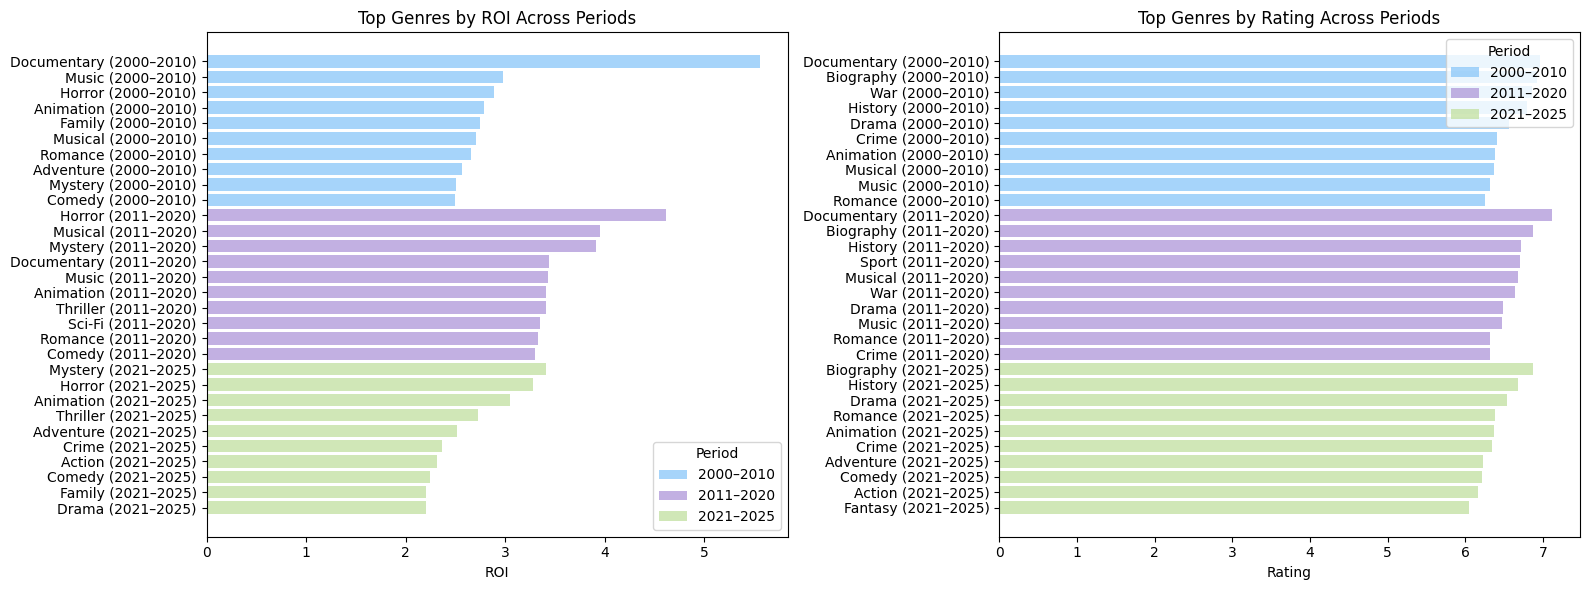

In [36]:

roi_df = genre_summary_df[genre_summary_df["type"] == "ROI"]
rating_df = genre_summary_df[genre_summary_df["type"] == "Rating"]


periods = roi_df["period"].unique()
colors = ["#90caf9", "#b39ddb", "#c5e1a5"]


fig, axes = plt.subplots(1, 2, figsize=(16,6))


for i, period in enumerate(periods):
    subset = roi_df[roi_df["period"] == period]

    axes[0].barh(
        subset["genre"] + " (" + period + ")",
        subset["value"],
        alpha=0.8,
        color=colors[i],
        label=period
    )

axes[0].set_title("Top Genres by ROI Across Periods")
axes[0].set_xlabel("ROI")
axes[0].invert_yaxis()
axes[0].legend(title="Period")



for i, period in enumerate(periods):
    subset = rating_df[rating_df["period"] == period]

    axes[1].barh(
        subset["genre"] + " (" + period + ")",
        subset["value"],
        alpha=0.8,
        color=colors[i],
        label=period
    )

axes[1].set_title("Top Genres by Rating Across Periods")
axes[1].set_xlabel("Rating")
axes[1].invert_yaxis()
axes[1].legend(title="Period")



plt.tight_layout()
plt.show()

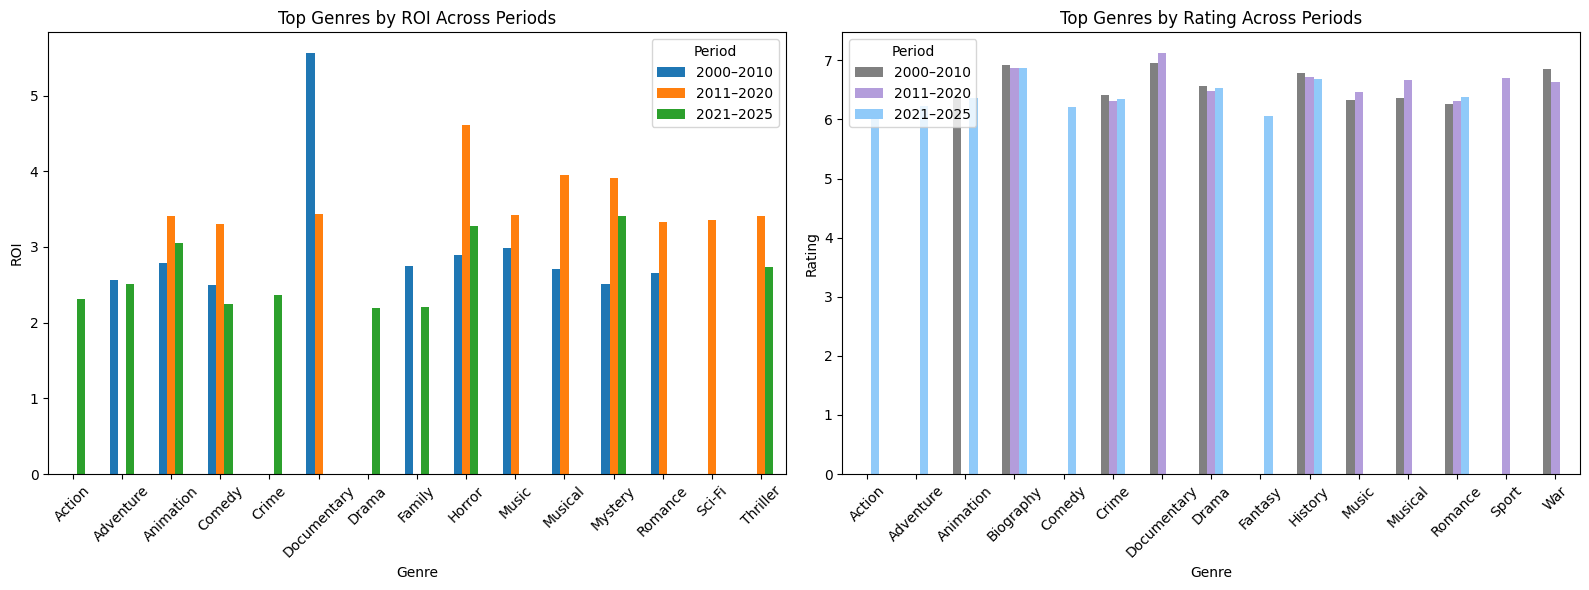

In [37]:
roi_df = genre_summary_df[genre_summary_df["type"] == "ROI"]
rating_df = genre_summary_df[genre_summary_df["type"] == "Rating"]

pivot_roi = roi_df.pivot(index="genre", columns="period", values="value").fillna(0)
pivot_rating = rating_df.pivot(index="genre", columns="period", values="value").fillna(0)


fig, axes = plt.subplots(1, 2, figsize=(16,6))

pivot_roi.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Top Genres by ROI Across Periods")
axes[0].set_ylabel("ROI")
axes[0].set_xlabel("Genre")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Period")


pivot_rating.plot(
    kind="bar",
    ax=axes[1],
    color=["gray", "#b39ddb", "#90caf9"]
)

axes[1].set_title("Top Genres by Rating Across Periods")
axes[1].set_ylabel("Rating")
axes[1].set_xlabel("Genre")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Period")

plt.tight_layout()
plt.show()

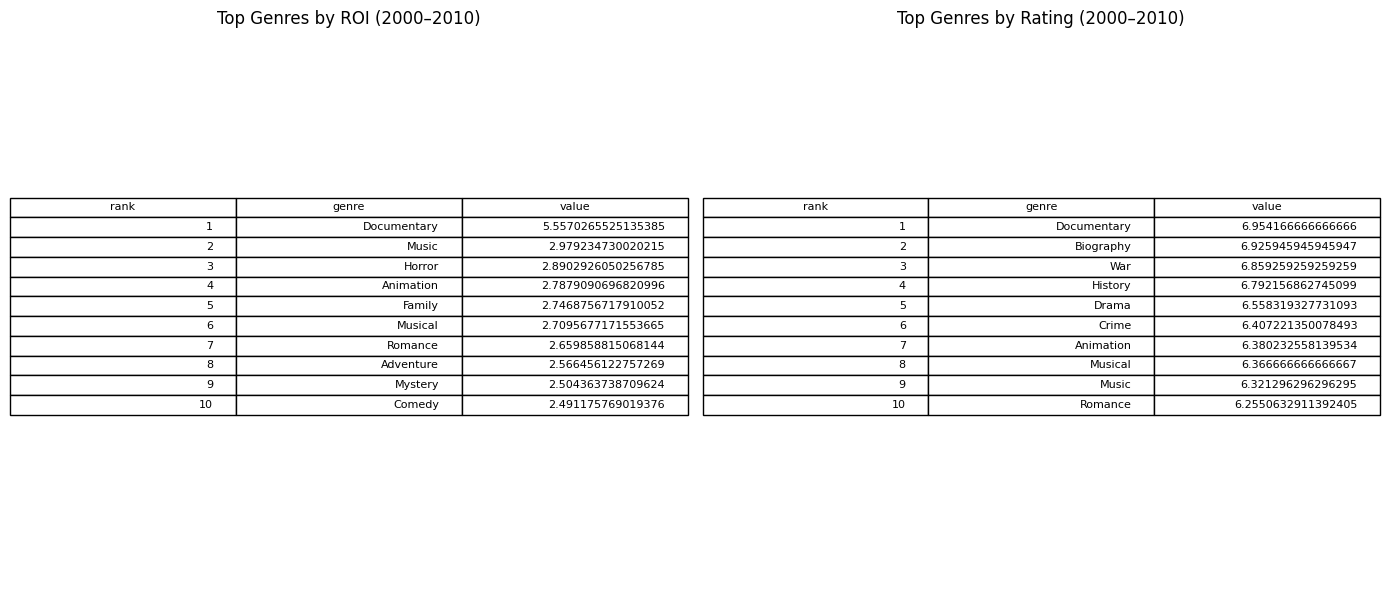

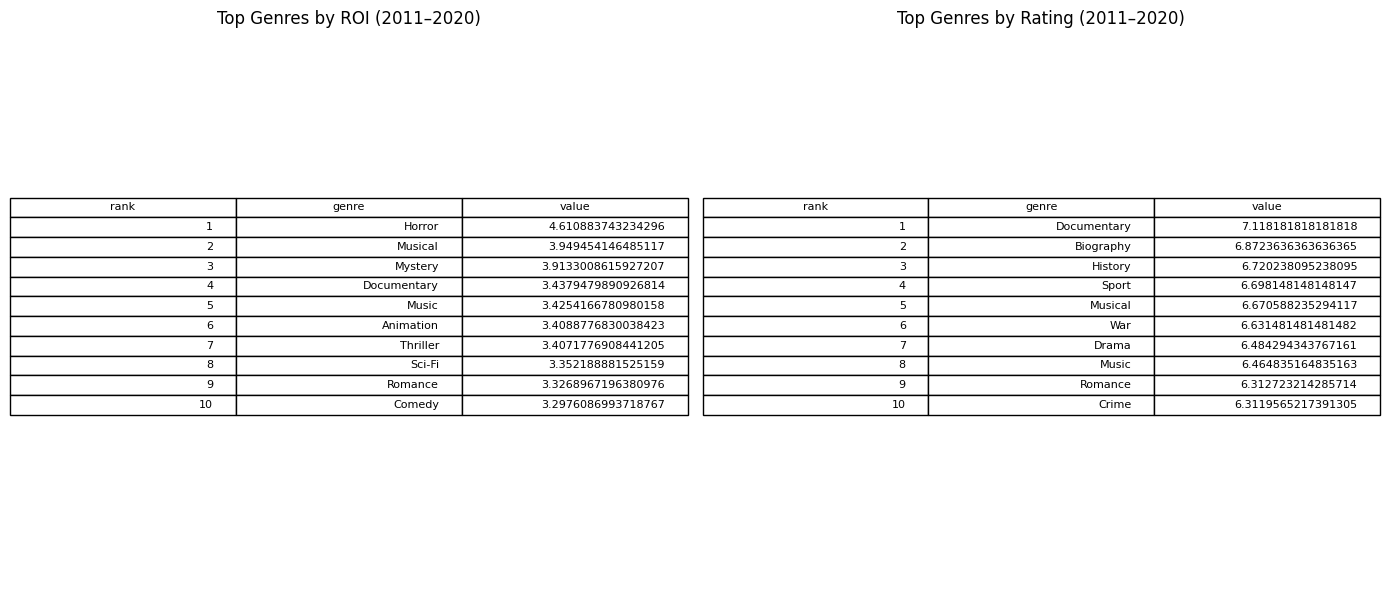

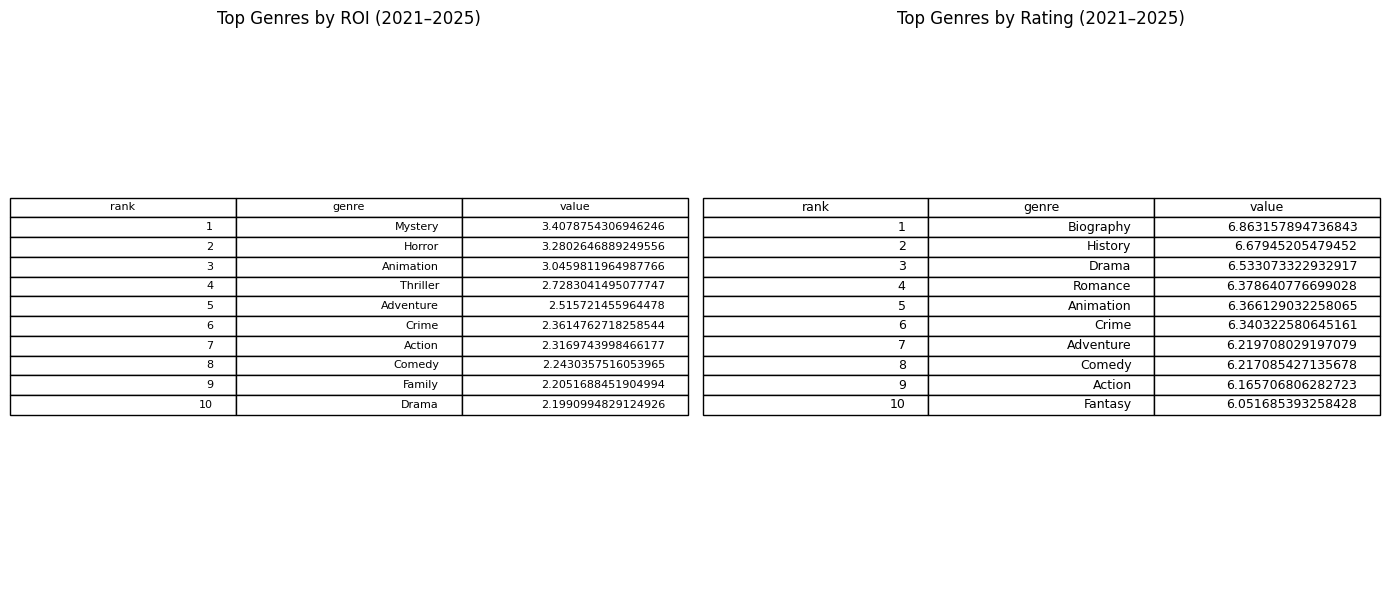

In [38]:

for period in periods:

    roi_table = genre_summary_df[
        (genre_summary_df["period"] == period) &
        (genre_summary_df["type"] == "ROI")
    ][["rank", "genre", "value"]]

    rating_table = genre_summary_df[
        (genre_summary_df["period"] == period) &
        (genre_summary_df["type"] == "Rating")
    ][["rank", "genre", "value"]]


    fig, axes = plt.subplots(1, 2, figsize=(14,6))

    # ROI TABLE
    axes[0].axis('off')
    axes[0].table(
        cellText=roi_table.values,
        colLabels=roi_table.columns,
        loc='center'
    )
    axes[0].set_title(f"Top Genres by ROI ({period})")

    # RATING TABLE
    axes[1].axis('off')
    axes[1].table(
        cellText=rating_table.values,
        colLabels=rating_table.columns,
        loc='center'
    )
    axes[1].set_title(f"Top Genres by Rating ({period})")

    plt.tight_layout()
    plt.show()

### Genre Shifts Across Time Periods

To assess how genre performance evolves, we compare top-performing genres across three periods: 2000–2010, 2011–2020, and 2021–2025.

#### Financial Performance (ROI)

Between 2000–2010 and 2011–2020, a clear shift occurs in financial leadership. Documentary dominates early with exceptionally high ROI (~ 5.56), but its influence declines in later periods. Instead, Horror (~ 4.61) and Mystery (~3.91) emerge as leading genres, indicating a transition toward suspense-driven, cost-efficient productions.

From 2011–2020 to 2021–2025, the structure remains similar, but leadership shifts slightly. Mystery (~ 3.41) overtakes Horror (~ 3.28), while Thriller and Animation remain among the top performers. Notably, Documentary disappears from the top ROI rankings entirely in the most recent period.

Overall, ROI rankings exhibit moderate shifts, but these changes occur within a consistent group of genres rather than introducing entirely new high-performing categories.

#### Audience Ratings

In contrast, genre rankings by rating remain highly stable across all periods. Documentary (~ 7.12) and Biography (~ 6.87) dominate earlier periods, while Biography (~ 6.86), History (~ 6.68), and Drama (~ 6.53) consistently appear among the top-rated genres.

Although Documentary drops out of the top rankings in the most recent period, the overall structure remains unchanged, with narrative-driven genres continuing to lead in audience ratings.

#### Key Insight

The comparison reveals a fundamental difference in how financial and audience-driven performance evolve over time:

- ROI rankings show gradual shifts, particularly the transition from Documentary dominance to Horror/Mystery leadership  
- Rating rankings remain structurally stable, with only minor changes  

This suggests that financial success is more sensitive to market dynamics, while audience preferences remain consistently aligned with narrative-driven content.

### Genre Combinations Over Time

We now extend the time-based analysis to genre combinations. Instead of splitting genres, each unique genre combination is treated as a distinct category.

In [39]:
# Store results for all periods
all_combo_tables = []

# Loop through each period
for period in periods:

    subset = movies[movies["period"] == period]

    # Aggregate metrics by genre combination
    combo_stats = subset.groupby("genres").agg(
        count=("title", "count"),
        avg_roi=("roi", "mean"),
        avg_rating=("rating", "mean")
    ).reset_index()

    # Keep only sufficiently large groups
    combo_stats = combo_stats[combo_stats["count"] >= 30]


    # TOP ROI
    top_roi = combo_stats.sort_values("avg_roi", ascending=False).head(10).reset_index(drop=True)
    top_roi["rank"] = top_roi.index + 1
    top_roi["type"] = "ROI"
    top_roi["period"] = period
    top_roi = top_roi.rename(columns={
        "genres": "genre",
        "avg_roi": "value"
    })

    # TOP RATING
    top_rating = combo_stats.sort_values("avg_rating", ascending=False).head(10).reset_index(drop=True)
    top_rating["rank"] = top_rating.index + 1
    top_rating["type"] = "Rating"
    top_rating["period"] = period
    top_rating = top_rating.rename(columns={
        "genres": "genre",
        "avg_rating": "value"
    })


    all_combo_tables.append(top_roi[["period","type","rank","genre","value"]])
    all_combo_tables.append(top_rating[["period","type","rank","genre","value"]])

combo_summary_df = pd.concat(all_combo_tables, ignore_index=True)

combo_summary_df.head(60)

,period,type,rank,genre,value
0,2000–2010,ROI,1,"Horror,Mystery,Thriller",3.950053
1,2000–2010,ROI,2,"Horror,Thriller",3.778094
2,2000–2010,ROI,3,Horror,3.710900
3,2000–2010,ROI,4,"Adventure,Animation,Comedy",3.164605
4,2000–2010,ROI,5,"Biography,Drama,History",3.095011
5,2000–2010,ROI,6,"Comedy,Drama,Romance",3.093695
6,2000–2010,ROI,7,"Comedy,Romance",2.863976
7,2000–2010,ROI,8,"Action,Crime,Drama",2.853953
8,2000–2010,ROI,9,"Crime,Drama",2.765098
9,2000–2010,ROI,10,Comedy,2.749002


### Visualization of Genre Combination Trends

To better understand how genre combinations perform across time, we visualize the top combinations by ROI and rating for each period.

In [40]:
combo_roi = combo_summary_df[combo_summary_df["type"] == "ROI"]
combo_rating = combo_summary_df[combo_summary_df["type"] == "Rating"]

periods = combo_roi["period"].unique()
colors = ["#4e79a7", "#b07aa1", "#59a14f"]

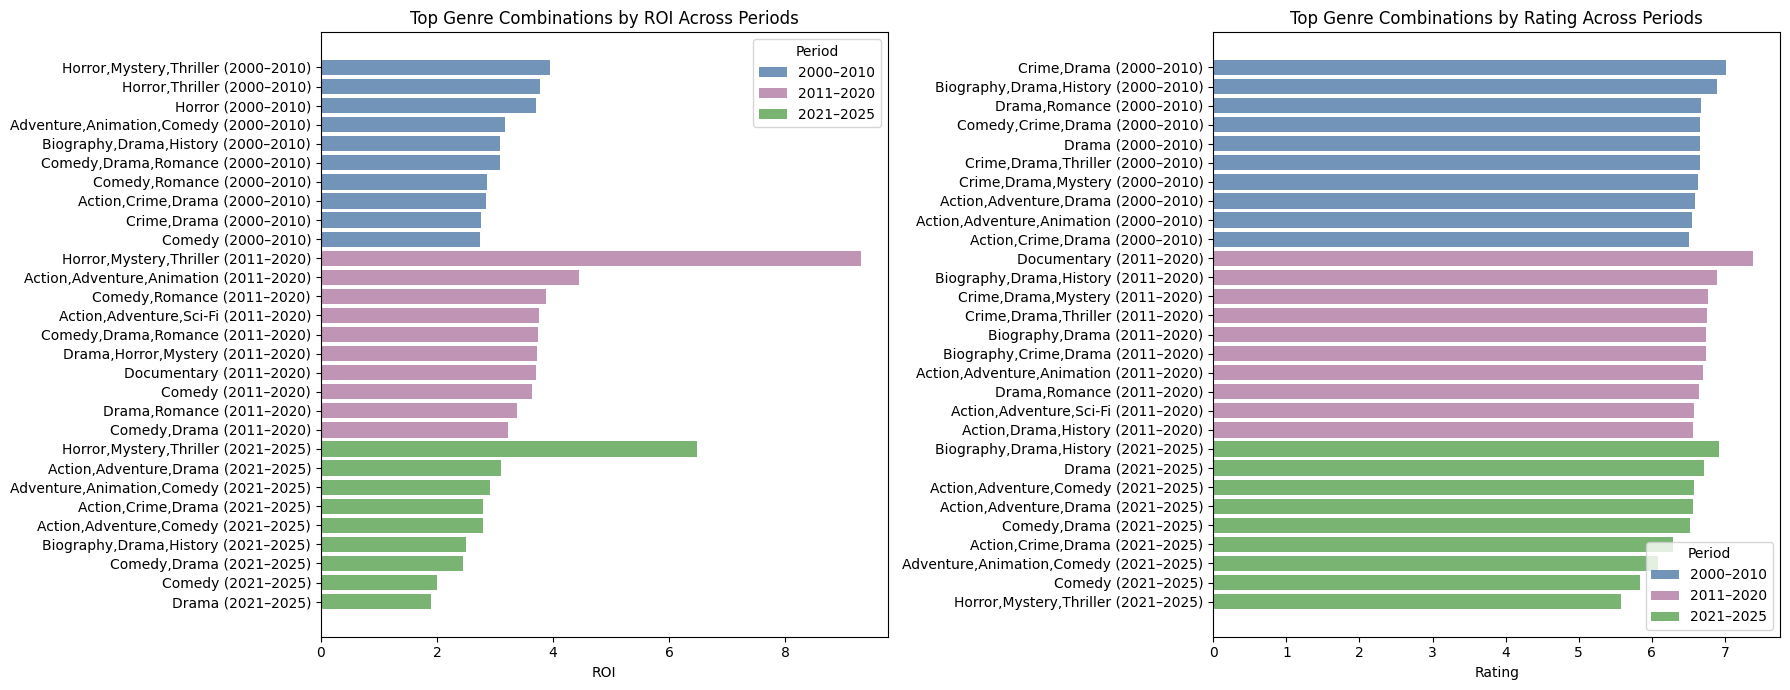

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18,7))


# ROI (LEFT)

for i, period in enumerate(periods):
    subset = combo_roi[combo_roi["period"] == period]

    axes[0].barh(
        subset["genre"] + " (" + period + ")",
        subset["value"],
        color=colors[i],
        alpha=0.8,
        label=period
    )

axes[0].set_title("Top Genre Combinations by ROI Across Periods")
axes[0].set_xlabel("ROI")
axes[0].invert_yaxis()
axes[0].legend(title="Period")


# RATING (RIGHT)

for i, period in enumerate(periods):
    subset = combo_rating[combo_rating["period"] == period]

    axes[1].barh(
        subset["genre"] + " (" + period + ")",
        subset["value"],
        color=colors[i],
        alpha=0.8,
        label=period
    )

axes[1].set_title("Top Genre Combinations by Rating Across Periods")
axes[1].set_xlabel("Rating")
axes[1].invert_yaxis()
axes[1].legend(title="Period")

plt.tight_layout()
plt.show()

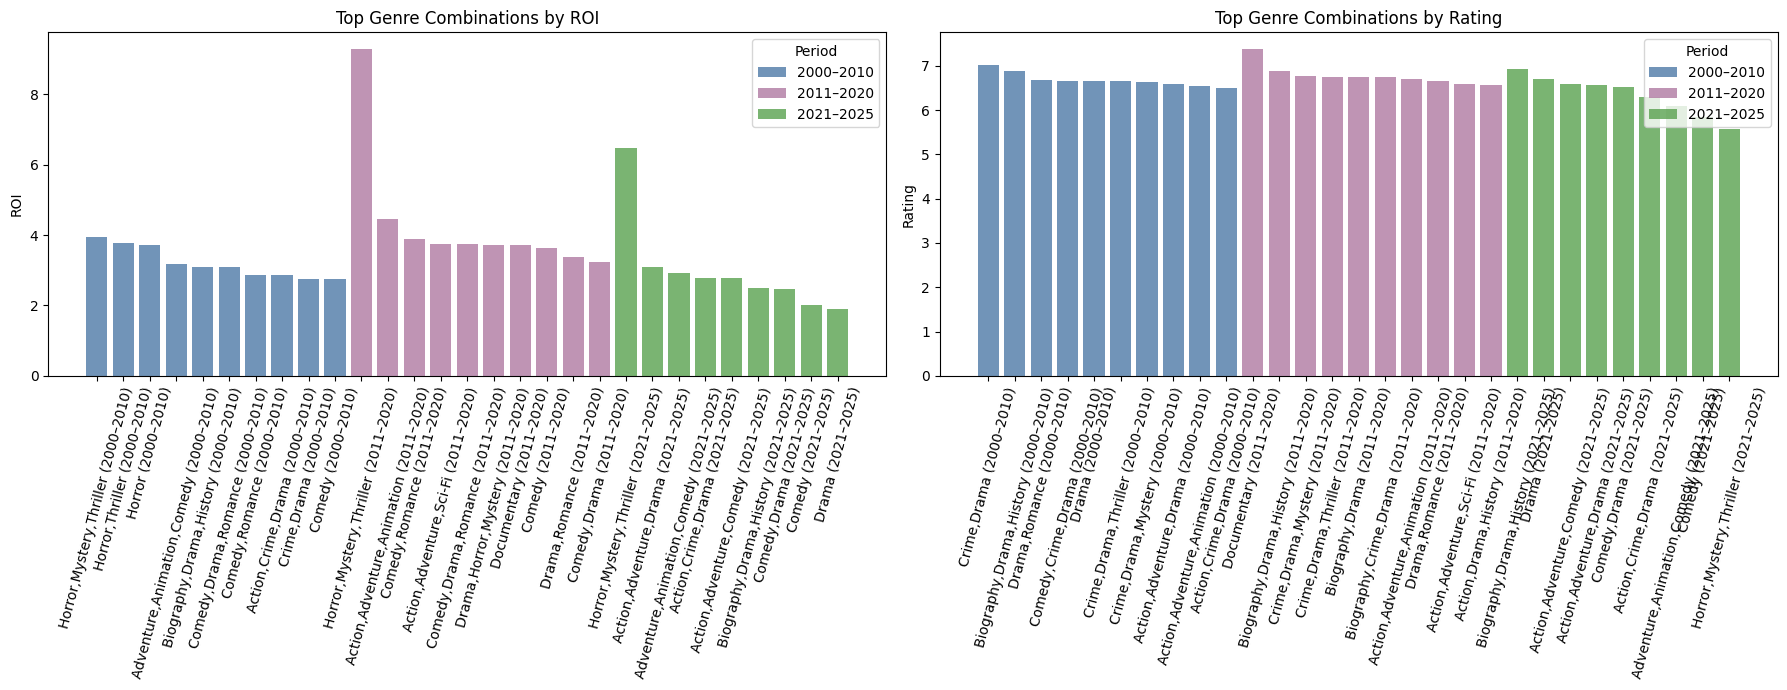

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(18,7))

# ROI
for i, period in enumerate(periods):
    subset = combo_roi[combo_roi["period"] == period]

    axes[0].bar(
        subset["genre"] + " (" + period + ")",
        subset["value"],
        color=colors[i],
        alpha=0.8,
        label=period
    )

axes[0].set_title("Top Genre Combinations by ROI")
axes[0].set_ylabel("ROI")
axes[0].tick_params(axis='x', rotation=75)
axes[0].legend(title="Period")

# Rating
for i, period in enumerate(periods):
    subset = combo_rating[combo_rating["period"] == period]

    axes[1].bar(
        subset["genre"] + " (" + period + ")",
        subset["value"],
        color=colors[i],
        alpha=0.8,
        label=period
    )

axes[1].set_title("Top Genre Combinations by Rating")
axes[1].set_ylabel("Rating")
axes[1].tick_params(axis='x', rotation=75)
axes[1].legend(title="Period")

plt.tight_layout()
plt.show()

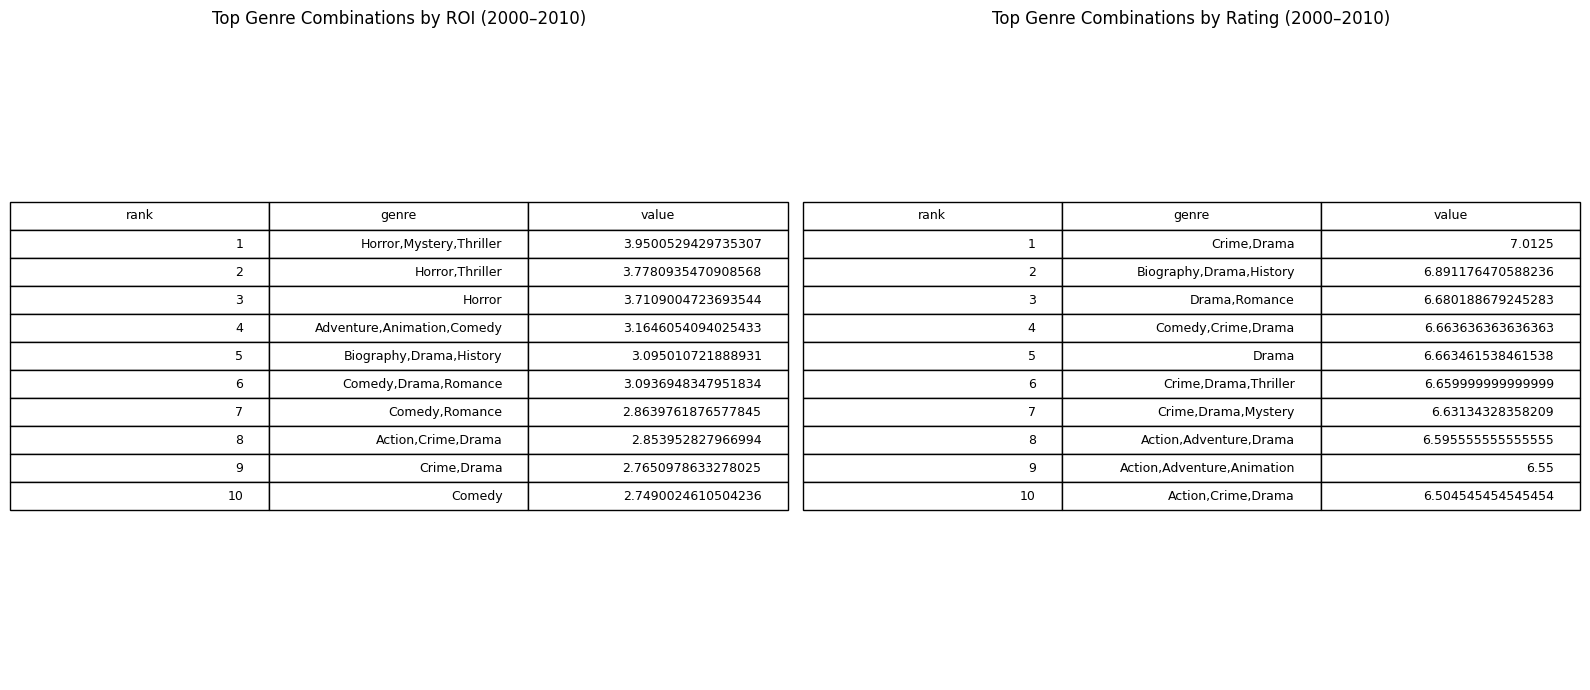

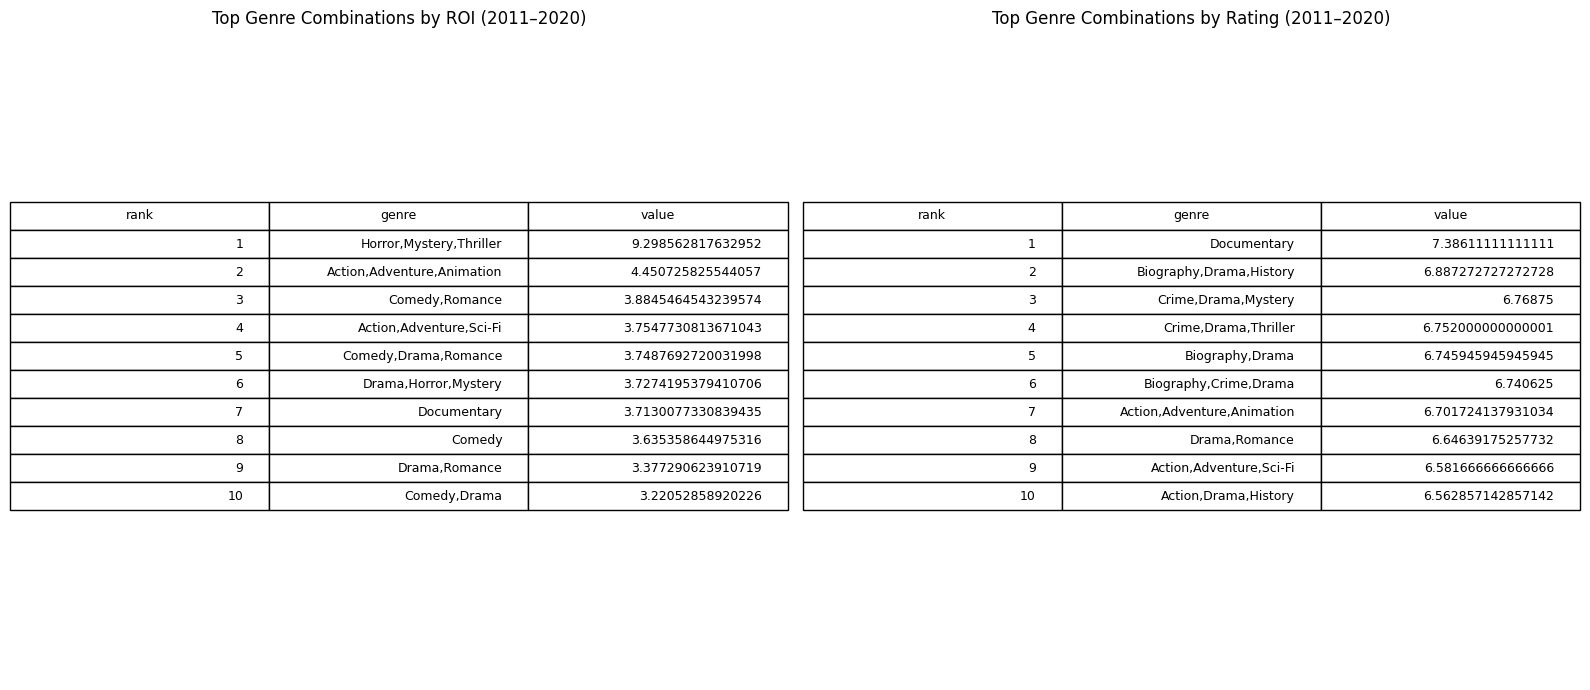

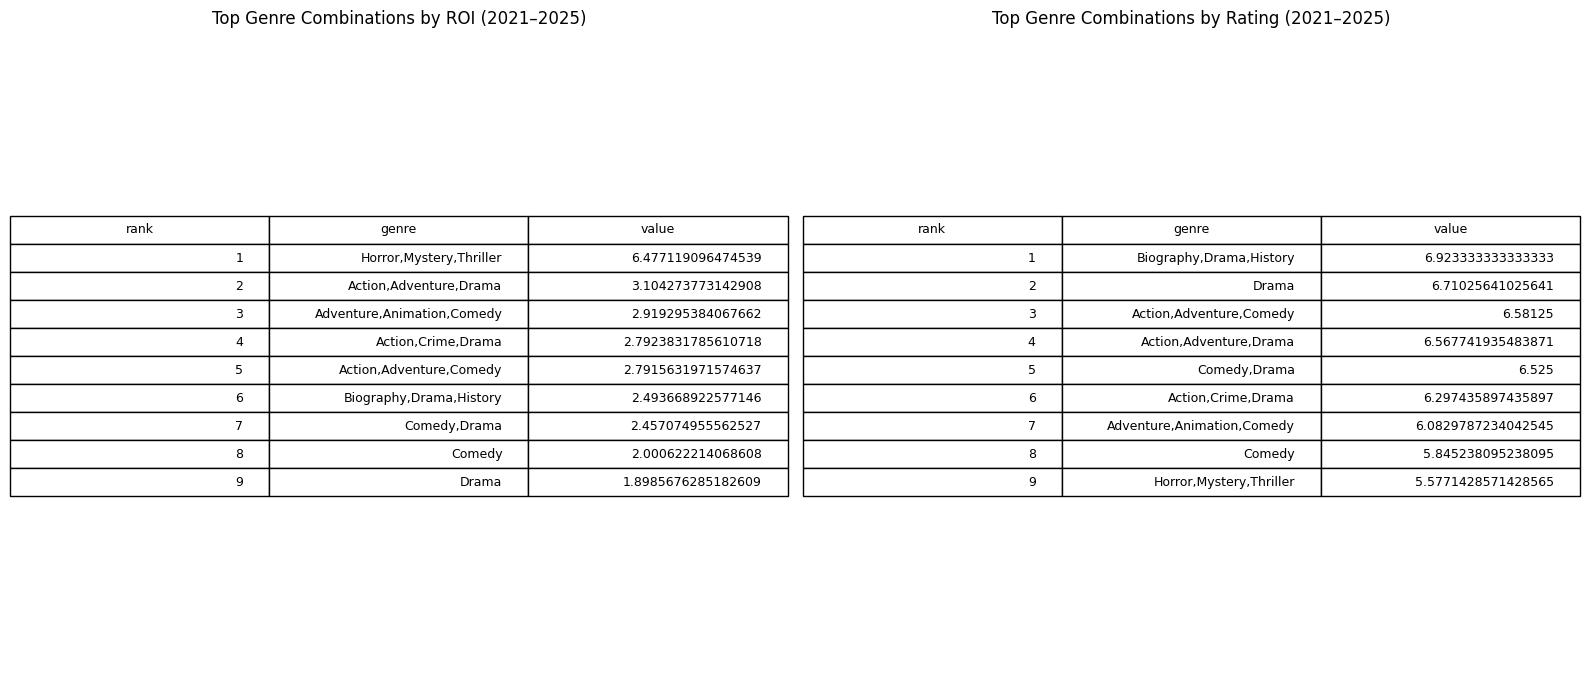

In [44]:
for period in periods:

    roi_table = combo_summary_df[
        (combo_summary_df["period"] == period) &
        (combo_summary_df["type"] == "ROI")
    ][["rank", "genre", "value"]]

    rating_table = combo_summary_df[
        (combo_summary_df["period"] == period) &
        (combo_summary_df["type"] == "Rating")
    ][["rank", "genre", "value"]]


    fig, axes = plt.subplots(1, 2, figsize=(16,7))


    # ROI TABLE

    axes[0].axis('off')
    table_roi = axes[0].table(
        cellText=roi_table.values,
        colLabels=roi_table.columns,
        loc='center'
    )
    table_roi.auto_set_font_size(False)
    table_roi.set_fontsize(9)
    table_roi.scale(1, 1.4)

    axes[0].set_title(f"Top Genre Combinations by ROI ({period})")



    # RATING TABLE

    axes[1].axis('off')
    table_rating = axes[1].table(
        cellText=rating_table.values,
        colLabels=rating_table.columns,
        loc='center'
    )
    table_rating.auto_set_font_size(False)
    table_rating.set_fontsize(9)
    table_rating.scale(1, 1.4)

    axes[1].set_title(f"Top Genre Combinations by Rating ({period})")

    plt.tight_layout()
    plt.show()

### Genre Combination Trends Over Time

#### Financial Performance (ROI)

Across all periods, **Horror–Mystery–Thriller** consistently appears as the top-performing combination:

- 2000–2010: ~3.95  
- 2011–2020: ~9.30 (clear outlier)  
- 2021–2025: ~6.48  

This indicates a highly stable and repeatable production model centered around suspense-driven genres.

While this combination remains dominant, the broader composition of top-performing combinations evolves moderately. Earlier periods include more Romance- and Drama-based mixes, while later periods show increased presence of Action–Adventure combinations.

#### Audience Ratings

Top-rated combinations remain consistently dominated by Drama-based mixes:

- 2000–2010: Crime–Drama (~ 7.01), Biography–Drama–History (~ 6.89)  
- 2011–2020: Documentary (~ 7.39), Biography–Drama–History (~ 6.89)  
- 2021–2025: Biography–Drama–History (~6.92)  

Unlike ROI, rating-based rankings remain highly stable across all periods.

#### Key Insight

- Financial performance is highly concentrated, with a small number of combinations consistently dominating ROI  
- Audience ratings remain stable and consistently favor narrative-driven combinations.

## Actor-Level Analysis

We now shift the focus from genre-level patterns to **actor-level dynamics** to better understand the role of cast in driving movie performance.

By aggregating financial and audience metrics at the actor level, we evaluate whether individual actors contribute to:

- Commercial success (ROI)  
- Audience reception (ratings)  

This analysis helps assess the extent to which **star power influences outcomes**, and whether success is driven by actors themselves or by the types of films they appear in.

### Building the Actor-Level Dataset

We construct an actor-level dataset by linking:

- Movie cast information  
- Movie financial and rating data  
- Actor identity (names)  

We then apply basic filtering to ensure consistency and remove categories that may distort comparisons.

In [45]:
# keep only actors
actor_cast = movie_principals[
    movie_principals["category"] == "actor"
]

# merge with movies
actor_cast = actor_cast.merge(
    movies,
    left_on="tconst",
    right_on="imdb_id",
    how="inner"
)

# add names
actor_cast = actor_cast.merge(
    movie_people_filtered[["nconst", "primaryName"]],
    on="nconst",
    how="left"
)

# remove documentaries
actor_cast = actor_cast[
    ~actor_cast["genres"].str.contains("Documentary", na=False)
]


actor_cast.head(2)

,tconst,ordering,nconst,category,job,characters,imdb_id,budget,revenue,year,title,runtime,genres,rating,numVotes,profit,roi,success,period,primaryName
0,tt0035423,1,nm0000212,actor,\N,"[""Kate McKay""]",tt0035423,48000000,76019048,2001,Kate & Leopold,118.0,"Comedy,Fantasy,Romance",6.4,93476.0,28019048,1.58373,0,2000–2010,Meg Ryan
1,tt0035423,2,nm0413168,actor,\N,"[""Leopold""]",tt0035423,48000000,76019048,2001,Kate & Leopold,118.0,"Comedy,Fantasy,Romance",6.4,93476.0,28019048,1.58373,0,2000–2010,Hugh Jackman


### Actor Performance Metrics

We aggregate performance metrics at the actor level across all movies they appear in.

Key metrics include:

- Average ROI → financial efficiency of films they participate in  
- Average rating → audience reception  
- Success rate → proportion of commercially successful films  
- Movie count → experience / sample size  

In [46]:

# Aggregate metrics per actor (across all movies)
actor_stats = actor_cast.groupby(["nconst", "primaryName"]).agg(
    avg_roi=("roi", "mean"),
    avg_rating=("rating", "mean"),
    success_rate=("success", "mean"),
    movies_count=("imdb_id", "count")
).reset_index()

# remove noise (basic filter)
actor_stats = actor_stats[actor_stats["movies_count"] >= 3]

# stronger filter for rankings
actor_stats_strong = actor_stats[actor_stats["movies_count"] > 5]


# TOP ACTORS

top_actor_roi = actor_stats_strong.sort_values("avg_roi", ascending=False).head(10)
top_actor_rating = actor_stats_strong.sort_values("avg_rating", ascending=False).head(10)

print("Top Actors by ROI")
print(top_actor_roi[["primaryName","avg_roi","movies_count"]])

print("\nTop Actors by Rating")
print(top_actor_rating[["primaryName","avg_rating","movies_count"]])

Top Actors by ROI
            primaryName    avg_roi  movies_count
5238      Richard Epcar  18.849672             9
11743     Angus Sampson  13.591868             7
29101   Glenn Berggoetz  13.431106             6
15679        Eric Bauza  13.423100            14
8934   William Mapother  11.513781             6
1523          Lin Shaye  11.178282             8
23264     Pierre Coffin  10.983511             9
5053       Mark Duplass  10.366654             6
20940     Jessica Rothe   9.203817             6
16277  Ryûnosuke Kamiki   9.154321             7

Top Actors by Rating
             primaryName  avg_rating  movies_count
6403        Kamal Haasan    7.825000             8
39148         Shafiq Isa    7.800000             6
5238       Richard Epcar    7.766667             9
14739         Sala Baker    7.700000             7
43     Leonardo DiCaprio    7.673684            19
24058     Anushka Shetty    7.628571             7
7995       Atul Kulkarni    7.585714             7
4896   Jean-C

### Initial Observation

The results show that actors with the highest average ROI are often not widely recognized. Instead, many of these actors appear in **lower-budget films** that generate strong returns relative to their cost.

This suggests that high ROI is not necessarily driven by star power, but rather by **cost-efficient production models**. Smaller-scale films are able to achieve strong financial efficiency even without high-profile actors.

At the same time, highly recognized actors (e.g., Leonardo DiCaprio) appear among the top performers in **ratings**, but not in ROI. This indicates that:

- Well-known actors are more strongly associated with **audience reception and perceived quality**  

Overall, actor-level results reinforce earlier findings: financial success (ROI) and audience perception (rating) represent **distinct dimensions of performance**, influenced by different underlying factors.

### Incorporating Production Scale

We now incorporate **production scale** by introducing average budget at the actor level. This allows us to examine whether established, high-profile actors—who are typically associated with larger-budget films—exhibit different performance patterns.

Specifically, we compare actors across three dimensions:
- **Average budget** (production scale)
- **Average ROI** (financial efficiency)
- **Average rating** (audience reception)

By analyzing these dimensions together, we aim to better understand how actor prominence, budget size, and performance outcomes are related.

In [47]:

# ADD AVG BUDGET

actor_stats = actor_cast.groupby(["nconst", "primaryName"]).agg(
    avg_roi=("roi", "mean"),
    avg_rating=("rating", "mean"),
    avg_budget=("budget", "mean"),
    success_rate=("success", "mean"),
    movies_count=("imdb_id", "count"),
    total_votes=("numVotes", "sum")
).reset_index()

actor_stats["avg_votes"] = actor_stats["total_votes"] / actor_stats["movies_count"]

actor_stats_filtered = actor_stats[
    (actor_stats["movies_count"] > 10) &
    (actor_stats["avg_votes"] > 50000)
]


# TOP BY BUDGET

top_budget = actor_stats_filtered.sort_values("avg_budget", ascending=False).head(10)

print("Top Actors by Budget")
print(top_budget[["primaryName", "avg_budget", "avg_roi", "avg_rating", "movies_count"]])


# TOP BY ROI

top_roi = actor_stats_filtered.sort_values("avg_roi", ascending=False).head(10)

print("\nTop Actors by ROI")
print(top_roi[["primaryName", "avg_roi", "avg_budget", "avg_rating", "movies_count"]])

# TOP BY RATING


top_rating = actor_stats_filtered.sort_values("avg_rating", ascending=False).head(10)

print("\nTop Actors by Rating")
print(top_rating[["primaryName", "avg_rating", "avg_roi", "avg_budget", "movies_count"]])

Top Actors by Budget
                primaryName    avg_budget   avg_roi  avg_rating  movies_count
27720             Gal Gadot  1.677000e+08  2.508300    6.146667            15
21076      Chadwick Boseman  1.668000e+08  4.016724    7.386667            15
31219           Tom Holland  1.451250e+08  4.362180    7.275000            16
3693           Henry Cavill  1.404375e+08  2.149036    6.600000            16
196             Don Cheadle  1.393600e+08  4.173543    7.084000            25
5273            Chris Evans  1.392788e+08  3.766877    6.996970            33
12015           Andy Serkis  1.389444e+08  3.469839    7.188889            18
225       Robert Downey Jr.  1.359265e+08  3.831615    7.176471            34
17304  Benedict Cumberbatch  1.349375e+08  4.633210    7.243750            16
10891           Chris Pratt  1.291071e+08  3.566712    6.782143            28

Top Actors by ROI
          primaryName   avg_roi    avg_budget  avg_rating  movies_count
2585       Tobin Bell  8.70206

### Actor Performance Across Budget, ROI, and Ratings

To ensure meaningful comparisons, we restrict the analysis to actors with substantial experience and audience exposure (movies_count > 10 and avg_votes > 50,000). This focuses the analysis on mainstream actors while reducing noise.

#### High-Budget Actors

Actors associated with the highest average budgets—such as **Gal Gadot, Tom Holland, Robert Downey Jr., and Chris Evans**—are strongly linked to large-scale franchise productions.

These actors consistently appear in films with budgets exceeding ~$130M–$170M. Despite the scale, they maintain solid performance levels, with:

- ROI typically around **2.5–4.5**  
- Ratings generally around **6.5–7.3**

This suggests that while blockbuster films are less efficient than low-budget productions, they still achieve strong commercial outcomes at scale.

#### High ROI Actors

Actors with the highest ROI—such as **Tobin Bell, Billy Burke, and James McAvoy**—tend to operate at **lower to mid budget levels**.

For example:
- Tobin Bell: ROI ~8.70, avg budget ~17M  
- Billy Burke: ROI ~8.01, avg budget ~50M  

These actors are often associated with cost-efficient productions, particularly in genres like horror or mid-scale commercial films.

This reinforces the earlier finding that **financial efficiency is driven more by production model than by budget size alone**.

#### High Rating Actors

Actors with the highest ratings—such as **Leonardo DiCaprio, Chadwick Boseman, and Timothée Chalamet**—are associated with a mix of mid- to high-budget films.

Their performance shows:
- Ratings consistently above **7.2**  
- ROI generally moderate (**~3–4.5**)  

This indicates that strong audience reception is not strictly tied to the highest budget levels, but rather to film quality and storytelling.

#### Key Insight

Comparing across all three dimensions reveals a clear separation:

- **High-budget actors** dominate large-scale franchise productions and maintain strong but moderate ROI  
- **High-ROI actors** achieve financial efficiency through lower-cost or mid-scale productions  
- **High-rating actors** are associated with critically successful films, often independent of extreme budget levels  

Only a small subset of actors (e.g., **Chadwick Boseman, Tom Holland, Benedict Cumberbatch**) perform strongly across multiple dimensions, combining scale, financial success, and audience reception.

Overall, actor performance reflects distinct industry roles. Star power is most strongly associated with production scale and visibility, while financial efficiency remains driven primarily by production economics rather than actor prominence alone.

Finally, while results depend on filtering thresholds, the overall patterns remain consistent: **budget, ROI, and rating capture different aspects of success and are not perfectly aligned.**

### Visualization of Actor Performance

To better compare actor performance across the three dimensions, we visualize:

- Top actors by average budget  
- Top actors by ROI  
- Top actors by rating  

These visualizations provide a comparison of how different actors specialize across production scale, financial efficiency, and audience reception.

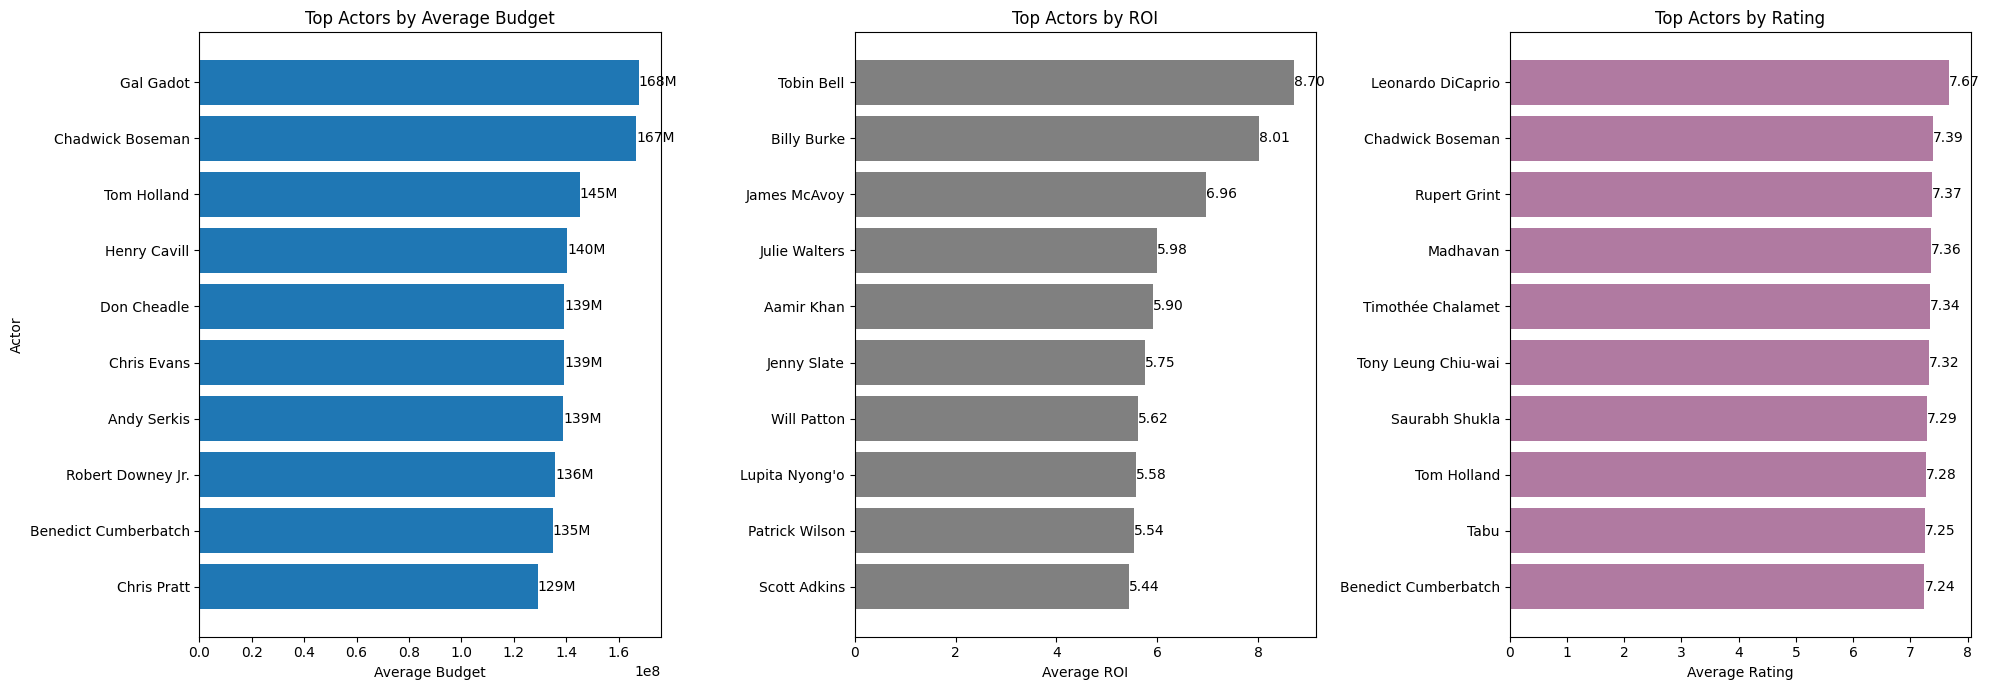

In [48]:
# build plots

top_budget_sorted = top_budget.sort_values("avg_budget", ascending=True)
top_roi_sorted = top_roi.sort_values("avg_roi", ascending=True)
top_rating_sorted = top_rating.sort_values("avg_rating", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20,7))


# TOP BY BUDGET

axes[0].barh(
    top_budget_sorted["primaryName"],
    top_budget_sorted["avg_budget"]
)

axes[0].set_title("Top Actors by Average Budget")
axes[0].set_xlabel("Average Budget")
axes[0].set_ylabel("Actor")

for i, v in enumerate(top_budget_sorted["avg_budget"]):
    axes[0].text(v, i, f"{v/1e6:.0f}M", va='center')



# TOP BY ROI

axes[1].barh(
    top_roi_sorted["primaryName"],
    top_roi_sorted["avg_roi"],
    color = "grey"
)

axes[1].set_title("Top Actors by ROI")
axes[1].set_xlabel("Average ROI")

for i, v in enumerate(top_roi_sorted["avg_roi"]):
    axes[1].text(v, i, f"{v:.2f}", va='center')



# TOP BY RATING

axes[2].barh(
    top_rating_sorted["primaryName"],
    top_rating_sorted["avg_rating"],
    color = "#b07aa1"
)

axes[2].set_title("Top Actors by Rating")
axes[2].set_xlabel("Average Rating")

for i, v in enumerate(top_rating_sorted["avg_rating"]):
    axes[2].text(v, i, f"{v:.2f}", va='center')


plt.tight_layout()
plt.show()

## Actor Performance Over Time (5-Year Periods)

To capture how actor performance evolves, we introduce finer time granularity using **5-year periods**.

Unlike genres, actor careers are dynamic—performance, popularity, and project selection can change significantly over relatively short time horizons.

By analyzing actors within each period, we aim to identify:

- How leading actors **emerge, persist, or decline**
- Whether **financial success (ROI)** and **audience reception (ratings)** evolve differently over time
- How the structure of **star power** changes across eras.

### Defining Time Periods

We divide the dataset into 5-year intervals to capture short- to medium-term shifts in actor performance and industry structure.

In [49]:
# define 5-year period function

def assign_period_5y(year):
    if year <= 2004:
        return "2000–2004"
    elif year <= 2009:
        return "2005–2009"
    elif year <= 2014:
        return "2010–2014"
    elif year <= 2019:
        return "2015–2019"
    else:
        return "2020–2025"

# add to movies

movies["period_5y"] = movies["year"].apply(assign_period_5y)

In [50]:
# Merge period into actor dataset

actor_cast_periods = actor_cast.merge(
    movies[["imdb_id", "period_5y"]],
    left_on="tconst",
    right_on="imdb_id",
    how="left"
)

actor_cast_periods = actor_cast_periods.rename(columns = {"imdb_id_x": "imdb_id"}).drop("imdb_id_y", axis = 1)

In [51]:
# Compute actor stats by period

actor_period_stats = actor_cast_periods.groupby(
    ["period_5y", "nconst", "primaryName"]
).agg(
    avg_roi=("roi", "mean"),
    avg_rating=("rating", "mean"),
    avg_budget=("budget", "mean"),
    success_rate=("success", "mean"),
    movies_count=("imdb_id", "count"),
    total_votes=("numVotes", "sum")
).reset_index()

# add avg votes
actor_period_stats["avg_votes"] = (
    actor_period_stats["total_votes"] / actor_period_stats["movies_count"]
)

In [52]:
# Apply filtering

actor_period_filtered = actor_period_stats[
    (actor_period_stats["movies_count"] > 3) &     # lower threshold for shorter periods
    (actor_period_stats["avg_votes"] >= 30000)
]

In [53]:
# Get top actors per period

all_actor_tables = []

periods = sorted(actor_period_filtered["period_5y"].unique())

for period in periods:

    subset = actor_period_filtered[
        actor_period_filtered["period_5y"] == period
    ]

    # TOP BUDGET

    top_budget = subset.sort_values("avg_budget", ascending=False).head(10).copy()
    top_budget["rank"] = range(1, len(top_budget)+1)
    top_budget["type"] = "Budget"
    top_budget["period"] = period
    top_budget = top_budget.rename(columns={"avg_budget": "value"})

    # TOP ROI

    top_roi = subset.sort_values("avg_roi", ascending=False).head(10).copy()
    top_roi["rank"] = range(1, len(top_roi)+1)
    top_roi["type"] = "ROI"
    top_roi["period"] = period
    top_roi = top_roi.rename(columns={"avg_roi": "value"})

    # TOP RATING

    top_rating = subset.sort_values("avg_rating", ascending=False).head(10).copy()
    top_rating["rank"] = range(1, len(top_rating)+1)
    top_rating["type"] = "Rating"
    top_rating["period"] = period
    top_rating = top_rating.rename(columns={"avg_rating": "value"})

    all_actor_tables.append(
        top_budget[["period","type","rank","primaryName","value"]]
    )
    all_actor_tables.append(
        top_roi[["period","type","rank","primaryName","value"]]
    )
    all_actor_tables.append(
        top_rating[["period","type","rank","primaryName","value"]]
    )

actor_period_summary = pd.concat(all_actor_tables, ignore_index=True)

In [44]:
for period in sorted(actor_period_summary["period"].unique()):
    print(f"\n===== {period} =====")
    display(actor_period_summary[actor_period_summary["period"] == period])


===== 2000–2004 =====


,period,type,rank,primaryName,value
0,2000–2004,Budget,1,Tobey Maguire,1.228571e+08
1,2000–2004,Budget,2,Orlando Bloom,1.162000e+08
2,2000–2004,Budget,3,Will Smith,1.084286e+08
3,2000–2004,Budget,4,Richard Roxburgh,1.038750e+08
4,2000–2004,Budget,5,Adoni Maropis,1.037500e+08
5,2000–2004,Budget,6,Tom Hanks,1.015000e+08
6,2000–2004,Budget,7,Brad Pitt,1.002857e+08
7,2000–2004,Budget,8,Tom Cruise,1.000000e+08
8,2000–2004,Budget,9,J.K. Simmons,9.933333e+07
9,2000–2004,Budget,10,Ewen Bremner,9.740000e+07



===== 2005–2009 =====


,period,type,rank,primaryName,value
30,2005–2009,Budget,1,Ryan Ochoa,1.531250e+08
31,2005–2009,Budget,2,Daryl Sabara,1.525000e+08
32,2005–2009,Budget,3,Emma Watson,1.525000e+08
33,2005–2009,Budget,4,Gary Oldman,1.458571e+08
34,2005–2009,Budget,5,Tobey Maguire,1.435000e+08
35,2005–2009,Budget,6,Orlando Bloom,1.403400e+08
36,2005–2009,Budget,7,Mackenzie Crook,1.401875e+08
37,2005–2009,Budget,8,Johnny Depp,1.400000e+08
38,2005–2009,Budget,9,Daniel Radcliffe,1.385000e+08
39,2005–2009,Budget,10,Bryce Dallas Howard,1.355500e+08



===== 2010–2014 =====


,period,type,rank,primaryName,value
60,2010–2014,Budget,1,Ian McKellen,2.500000e+08
61,2010–2014,Budget,2,William Kircher,2.500000e+08
62,2010–2014,Budget,3,Ian McShane,2.110000e+08
63,2010–2014,Budget,4,Ken Stott,1.912500e+08
64,2010–2014,Budget,5,Richard Armitage,1.880000e+08
65,2010–2014,Budget,6,Nicholas Hoult,1.825000e+08
66,2010–2014,Budget,7,Andrew Garfield,1.475000e+08
67,2010–2014,Budget,8,Johnny Depp,1.420000e+08
68,2010–2014,Budget,9,Hugh Jackman,1.402857e+08
69,2010–2014,Budget,10,Martin Freeman,1.396667e+08



===== 2015–2019 =====


,period,type,rank,primaryName,value
90,2015–2019,Budget,1,Mark Hamill,3.047167e+08
91,2015–2019,Budget,2,Don Cheadle,2.852500e+08
92,2015–2019,Budget,3,Robert Downey Jr.,2.632000e+08
93,2015–2019,Budget,4,Chris Evans,2.329000e+08
94,2015–2019,Budget,5,Henry Cavill,2.255000e+08
95,2015–2019,Budget,6,Daisy Ridley,2.193800e+08
96,2015–2019,Budget,7,Mark Ruffalo,2.092727e+08
97,2015–2019,Budget,8,John Boyega,2.061500e+08
98,2015–2019,Budget,9,Chadwick Boseman,2.005833e+08
99,2015–2019,Budget,10,Jeremy Renner,1.918000e+08



===== 2020–2025 =====


,period,type,rank,primaryName,value
120,2020–2025,Budget,1,Pom Klementieff,2.737500e+08
121,2020–2025,Budget,2,Hayley Atwell,2.387500e+08
122,2020–2025,Budget,3,Chris Pratt,2.250000e+08
123,2020–2025,Budget,4,Zoe Saldaña,2.190000e+08
124,2020–2025,Budget,5,Jeff Goldblum,2.117500e+08
125,2020–2025,Budget,6,Vin Diesel,2.080000e+08
126,2020–2025,Budget,7,Harrison Ford,1.909250e+08
127,2020–2025,Budget,8,Javier Bardem,1.904000e+08
128,2020–2025,Budget,9,Ving Rhames,1.895000e+08
129,2020–2025,Budget,10,Alan Tudyk,1.880000e+08


### Visualization of Actor Trends Over Time

We visualize top actors across periods to highlight:

- The evolution of high-budget actors (blockbuster trends)
- The stability or turnover of high-ROI actors
- Changes in top-rated actors over time

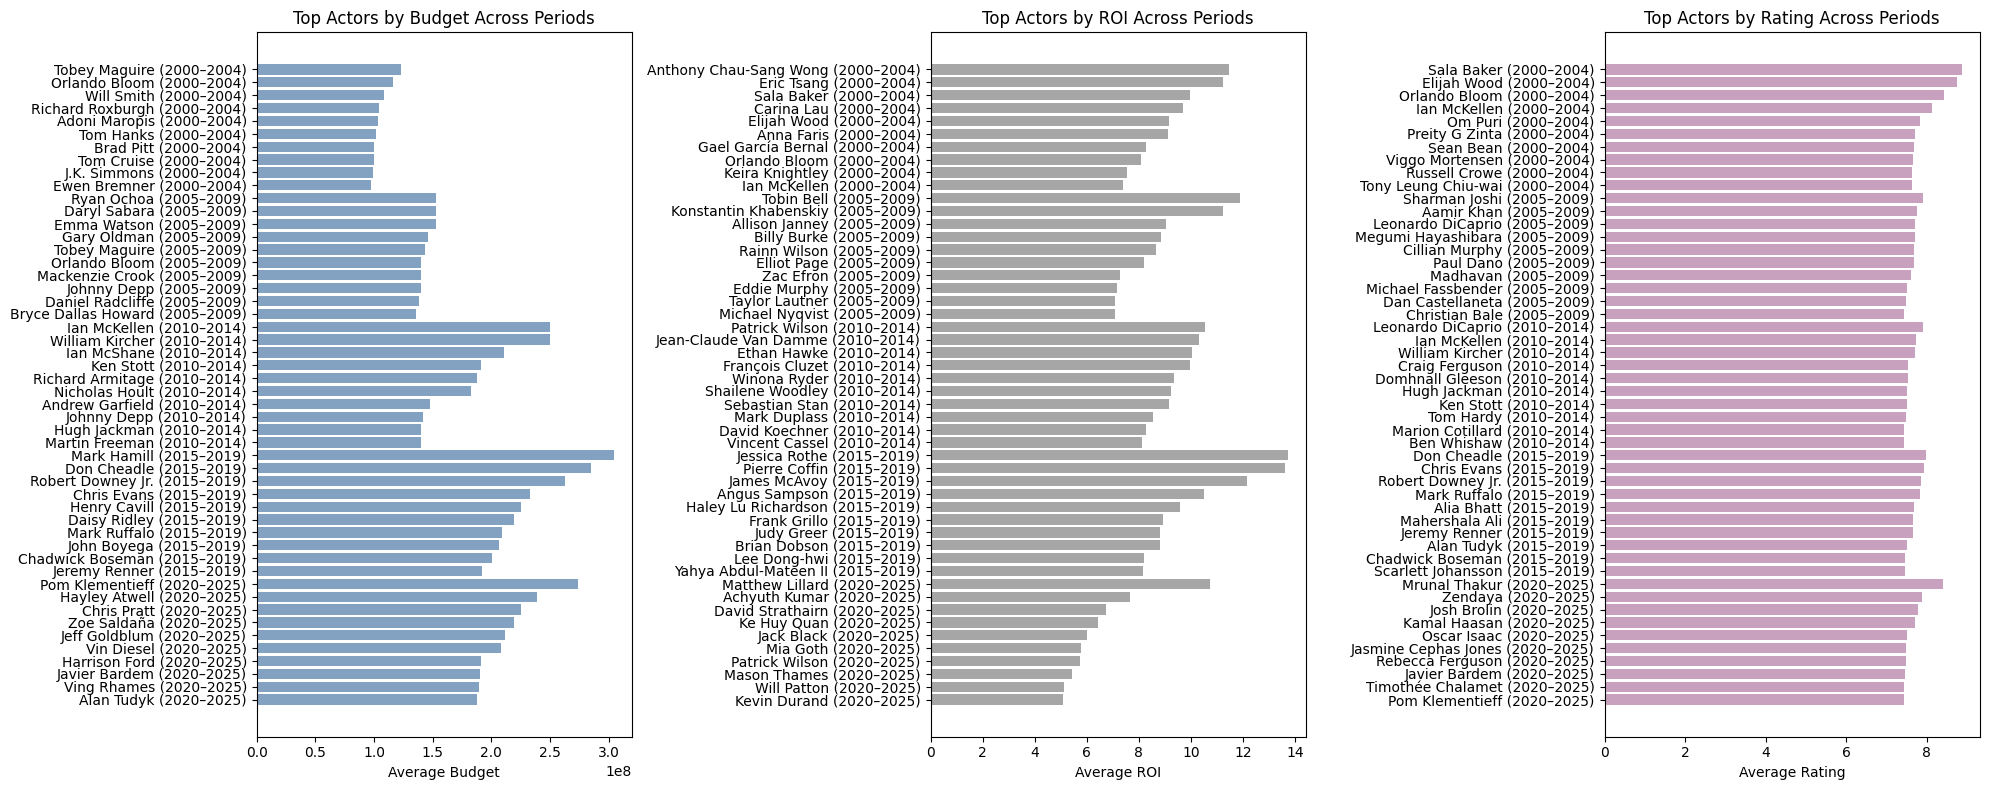

In [54]:
# split by type

budget_df = actor_period_summary[actor_period_summary["type"] == "Budget"]
roi_df = actor_period_summary[actor_period_summary["type"] == "ROI"]
rating_df = actor_period_summary[actor_period_summary["type"] == "Rating"]

# period order

periods = ["2000–2004", "2005–2009", "2010–2014", "2015–2019", "2020–2025"]

# colors
colors = {
    "Budget": "#4e79a7",   # blue
    "ROI": "gray",
    "Rating": "#b07aa1"    # purple
}

# CREATE 3 PLOTS

fig, axes = plt.subplots(1, 3, figsize=(20,8))


# BUDGET

for period in periods:
    subset = budget_df[budget_df["period"] == period].sort_values("value", ascending=False)

    axes[0].barh(
        subset["primaryName"] + " (" + period + ")",
        subset["value"],
        color=colors["Budget"],
        alpha=0.7
    )

axes[0].set_title("Top Actors by Budget Across Periods")
axes[0].set_xlabel("Average Budget")
axes[0].invert_yaxis()


# ROI

for period in periods:
    subset = roi_df[roi_df["period"] == period].sort_values("value", ascending=False)

    axes[1].barh(
        subset["primaryName"] + " (" + period + ")",
        subset["value"],
        color=colors["ROI"],
        alpha=0.7
    )

axes[1].set_title("Top Actors by ROI Across Periods")
axes[1].set_xlabel("Average ROI")
axes[1].invert_yaxis()


# RATING

for period in periods:
    subset = rating_df[rating_df["period"] == period].sort_values("value", ascending=False)

    axes[2].barh(
        subset["primaryName"] + " (" + period + ")",
        subset["value"],
        color=colors["Rating"],
        alpha=0.7
    )

axes[2].set_title("Top Actors by Rating Across Periods")
axes[2].set_xlabel("Average Rating")
axes[2].invert_yaxis()


plt.tight_layout()
plt.show()

## Actor Performance Evolution Over Time

Analyzing actor performance across 5-year periods reveals how the relationship between **budget (scale)**, **ROI (efficiency)**, and **rating (quality)** evolves over time.

---

### 2000–2004: Strong Alignment Driven by Major Franchises

This period shows clear overlap across all three dimensions.

- **Budget leaders** (Tobey Maguire, Orlando Bloom, Will Smith) are tied to major blockbusters and early franchises (Spider-Man, LOTR, Men in Black).
- **ROI leaders** include both:
  - Franchise actors (Elijah Wood, Orlando Bloom, Ian McKellen)
  - Smaller-scale or international actors (Gael García Bernal, Anna Faris)
- **Rating leaders** strongly overlap with franchise actors (Elijah Wood, Ian McKellen, Sean Bean, Viggo Mortensen)

**Key pattern:**  
A small number of highly successful films (especially *The Lord of the Rings*) drive both financial success and ratings, creating strong alignment between all metrics.

---

### 2005–2009: Separation Between Scale and Performance

The structure becomes more fragmented.

- **Budget leaders** are dominated by franchise ecosystems (Harry Potter, Pirates of the Caribbean), including Emma Watson, Daniel Radcliffe, Johnny Depp, Orlando Bloom.
- **ROI leaders** shift away from these actors (Tobin Bell, Billy Burke, Zac Efron), indicating efficiency comes from different types of films.
- **Rating leaders** (DiCaprio, Christian Bale, Cillian Murphy) are largely disconnected from both budget and ROI rankings.

**Key pattern:**  
Budget, ROI, and rating diverge, with each dimension driven by different actors and types of films.

---

### 2010–2014: Scaling Up Without Convergence

Budgets increase significantly, but alignment does not return.

- **Budget leaders** (Ian McKellen, Martin Freeman, Andrew Garfield) reflect large-scale productions (e.g., *The Hobbit*, superhero films).
- **ROI leaders** (Patrick Wilson, Ethan Hawke) remain separate, driven by efficient or mid-budget films.
- **Rating leaders** (DiCaprio, Tom Hardy, Marion Cotillard) reflect prestige and critically successful cinema.

**Key pattern:**  
Industry scale grows, but financial efficiency and critical success remain disconnected from blockbuster actors.

---

### 2015–2019: Franchise Dominance with Partial Overlap

Franchises dominate the industry.

- **Budget leaders** are almost entirely franchise actors (Robert Downey Jr., Chris Evans, Mark Ruffalo, Chadwick Boseman).
- **Rating leaders** now significantly overlap with budget (many Marvel actors appear in both lists).
- **ROI leaders** (Jessica Rothe, James McAvoy) remain largely separate.

**Key pattern:**  
A partial convergence emerges — blockbuster actors begin to achieve both high budgets and strong ratings, but ROI remains independent.

---

### 2020–2025: Fragmentation with Distinct Actor Roles

The structure remains separated, but the drivers behind each dimension become more clearly differentiated.

- **Budget leaders** (Chris Pratt, Zoe Saldaña, Harrison Ford) reflect different sources of high-budget production:
  - Active multi-franchise actors (Pratt → Marvel, Jurassic World)
  - Multi-franchise participation (Saldaña → Avatar, Marvel)
  - Legacy franchise continuation (Ford → Star Wars, Indiana Jones)

- **ROI leaders** (Matthew Lillard, Ke Huy Quan, Mia Goth, Patrick Wilson) are clearly separate from the budget group and are associated with:
  - mid- to low-budget productions
  - genre-driven or scalable films

- **Rating leaders** (Zendaya, Timothée Chalamet, Oscar Isaac, Javier Bardem) represent:
  - a mix of mainstream visibility and critically strong films
  - minimal overlap with either ROI or budget leaders

**Key pattern:**  
The separation is now fully established:

- **Budget → franchise-driven and legacy productions**  
- **ROI → cost-efficient, non-blockbuster films**  
- **Rating → critically strong and/or mainstream actors**

---

## Final Insight

Across all periods, the industry evolves in scale and actors, but the underlying structure stabilizes after the early 2000s:

- **Early 2000s → strong alignment** driven by a few dominant franchises  
- **Later periods → clear separation** between:
  - Production scale (budget)
  - Financial efficiency (ROI)
  - Audience perception (rating)

Overall, actor performance reflects **distinct industry roles rather than a single unified notion of success**, with different types of actors driving different dimensions of movie performance.



## Director Level Analysis

In addition to actors, directors play a critical role in shaping both the financial and artistic outcomes of films. While actors influence on-screen performance and audience appeal, directors define storytelling, pacing, and overall creative direction.

To better understand this impact, we analyze director performance across three key dimensions:

- Financial efficiency (ROI)  
- Audience reception (ratings)  
- Production scale (budget)  


In [55]:
# Build a Director Dataset

director_data = movie_principals[
    movie_principals["category"] == "director"
]

director_data = director_data.merge(
    movies,
    left_on="tconst",
    right_on="imdb_id",
    how="inner"
)

director_data = director_data.merge(
    movie_people_filtered[["nconst", "primaryName"]],
    on="nconst",
    how="left"
)

director_data = director_data[
    ~director_data["genres"].str.contains("Documentary", na=False)
]

In [47]:
director_data.head(2)

,tconst,ordering,nconst,category,job,characters,imdb_id,budget,revenue,year,...,runtime,genres,rating,numVotes,profit,roi,success,period,period_5y,primaryName
0,tt0035423,11,nm0003506,director,\N,\N,tt0035423,48000000,76019048,2001,...,118.0,"Comedy,Fantasy,Romance",6.4,93476.0,28019048,1.583730,0,2000–2010,2000–2004,James Mangold
1,tt0113026,11,nm0006916,director,\N,\N,tt0113026,10000000,49666,2000,...,86.0,"Musical,Romance",5.7,1488.0,-9950334,0.004967,0,2000–2010,2000–2004,Michael Ritchie


In [56]:
# DIRECTOR METRICS

director_stats = director_data.groupby(["nconst", "primaryName"]).agg(
    avg_roi=("roi", "mean"),
    avg_rating=("rating", "mean"),
    avg_budget=("budget", "mean"),
    success_rate=("success", "mean"),
    movies_count=("imdb_id", "count"),
    total_votes=("numVotes", "sum")
).reset_index()

# compute avg votes
director_stats["avg_votes"] = (
    director_stats["total_votes"] / director_stats["movies_count"]
)

# filter (similar logic to actors)
director_stats_filtered = director_stats[
    (director_stats["movies_count"] > 5) &
    (director_stats["avg_votes"] > 50000)
]

In [57]:
# TOP BY BUDGET
top_director_budget = director_stats_filtered.sort_values(
    "avg_budget", ascending=False
).head(10)

# TOP BY ROI
top_director_roi = director_stats_filtered.sort_values(
    "avg_roi", ascending=False
).head(10)

# TOP BY RATING
top_director_rating = director_stats_filtered.sort_values(
    "avg_rating", ascending=False
).head(10)

print("Top Directors by Budget")
print(top_director_budget[["primaryName","avg_budget","avg_roi","avg_rating","movies_count"]])

print("\nTop Directors by ROI")
print(top_director_roi[["primaryName","avg_roi","avg_budget","avg_rating","movies_count"]])

print("\nTop Directors by Rating")
print(top_director_rating[["primaryName","avg_rating","avg_roi","avg_budget","movies_count"]])

Top Directors by Budget
                primaryName    avg_budget   avg_roi  avg_rating  movies_count
349             J.J. Abrams  2.124833e+08  3.921945    7.250000             6
2299            David Yates  1.918750e+08  4.541082    7.125000             8
1897          Anthony Russo  1.910000e+08  3.797141    7.242857             7
1898              Joe Russo  1.910000e+08  3.797141    7.242857             7
256   Christopher McQuarrie  1.694167e+08  3.163381    7.250000             6
172           Peter Jackson  1.610000e+08  6.112076    7.937500             8
83                Sam Raimi  1.610000e+08  3.332522    6.814286             7
1533           Rob Marshall  1.522857e+08  3.002819    6.657143             7
1090             James Gunn  1.496429e+08  2.461402    7.271429             7
2220         Lana Wachowski  1.480000e+08  1.948020    6.366667             6

Top Directors by ROI
             primaryName   avg_roi    avg_budget  avg_rating  movies_count
1398  Christopher Lan

## Initial Observation

### High-Budget Directors

Directors with the highest average budgets—such as J.J. Abrams, David Yates, the Russo brothers, and Christopher McQuarrie—are strongly associated with large-scale franchise and studio productions.

These directors operate at the highest production scale (often exceeding $150M per film) and maintain:
- solid ROI (~3–4.5)
- consistently strong ratings (~7+)

An important exception is Peter Jackson, who stands out as a rare case combining:
- very high budget (~$160M)
- strong ROI (~6.1)
- excellent ratings (~7.94)

This suggests that while most high-budget directors prioritize scale and stability, only a few successfully combine scale with exceptional efficiency and quality.


### High ROI Directors

Directors with the highest ROI—such as Christopher Landon, James Wan, and Scott Derrickson—operate under a very different production model.

Key characteristics:
- significantly lower budgets (often $5M–$70M)
- very high ROI (8–10+)
- moderate ratings (~5.5–6.7)

This indicates that financial efficiency is driven by:
- cost control
- genre specialization (especially horror/thriller)
- scalable production strategies

Notably, some directors such as Bong Joon Ho and Peter Jackson appear in both ROI and rating rankings, suggesting the ability to balance efficiency with quality.


### High Rating Directors

Top-rated directors—such as Christopher Nolan, Denis Villeneuve, and Quentin Tarantino—are consistently associated with critically acclaimed films.

These directors:
- achieve the highest ratings (~7.5–8.2)
- operate at mid-to-high budgets
- maintain moderate ROI (~2–4)

This reinforces the idea that:
**critical success is not optimized for financial efficiency**

Instead, these directors prioritize:
- storytelling
- artistic quality
- audience reception


### Key Insight

Across all three dimensions, a clear structural separation emerges:

- **Budget → large-scale, franchise-driven production**
- **ROI → cost-efficient, often genre-focused filmmaking**
- **Rating → narrative quality and critical success**

There is limited overlap between these groups, with only a few directors (e.g., Peter Jackson, Bong Joon Ho) performing strongly across multiple dimensions.

Overall, director performance reflects distinct roles within the film industry rather than a single unified definition of success.

In [58]:
# Correlation check
director_stats_filtered[["avg_budget","avg_roi","avg_rating"]].corr()

# Budget and ROI are weakly correlated

,avg_budget,avg_roi,avg_rating
avg_budget,1.000000,-0.016679,0.289223
avg_roi,-0.016679,1.000000,-0.035631
avg_rating,0.289223,-0.035631,1.000000


### Visualization of Director Performance

To better compare director performance across dimensions, we visualize:

- Top directors by average budget (production scale)  
- Top directors by ROI (financial efficiency)  
- Top directors by rating (audience reception)  

These visualizations help highlight differences in how directors contribute to movie success.

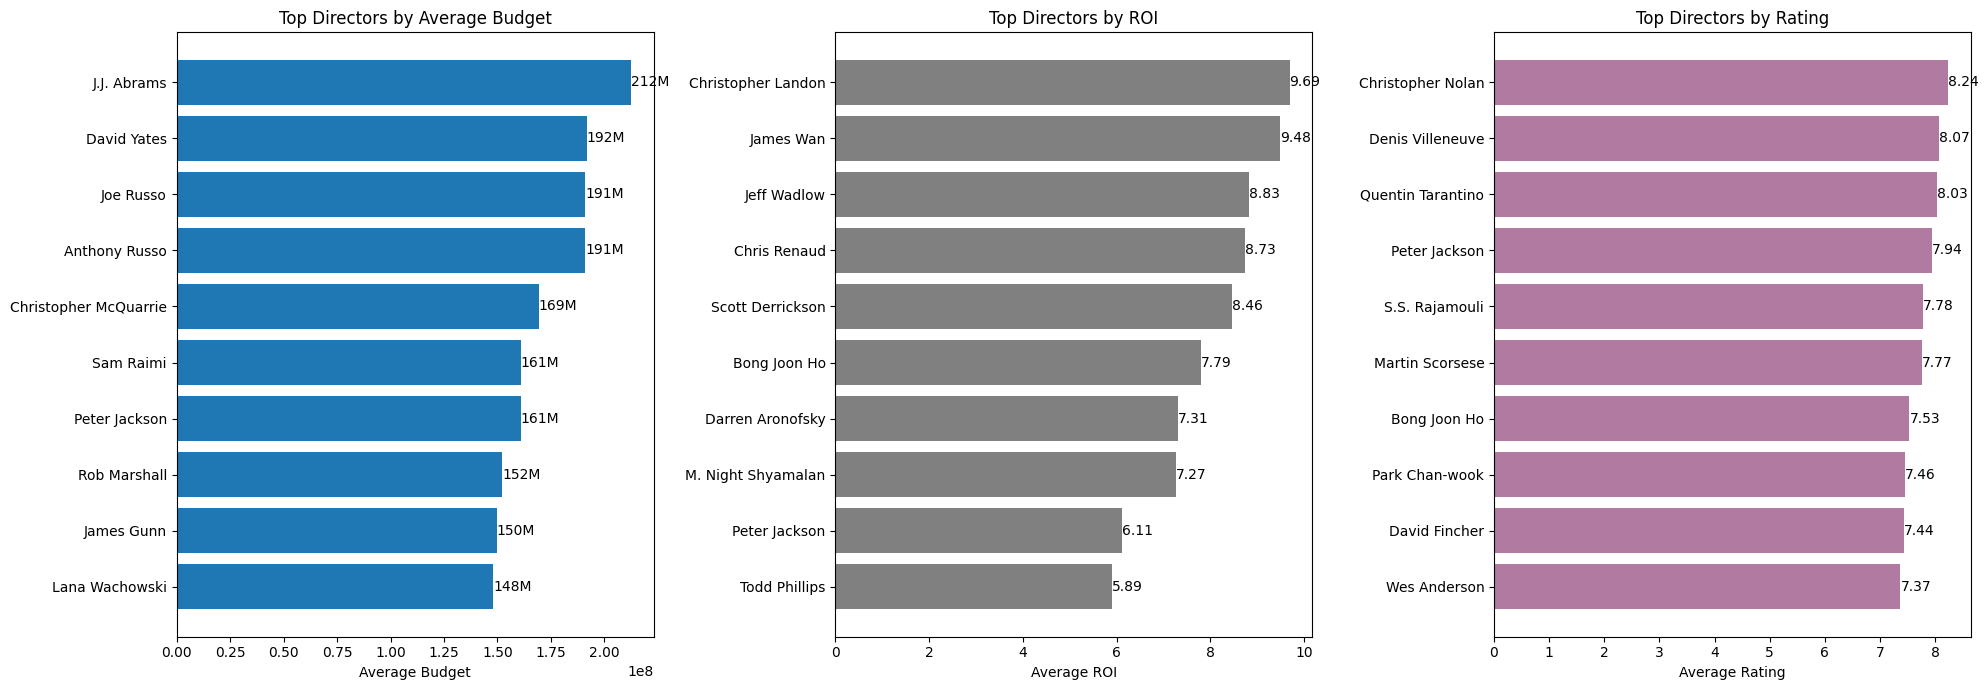

In [59]:
# BUILD PLOTS

top_budget_sorted = top_director_budget.sort_values("avg_budget", ascending=True)
top_roi_sorted = top_director_roi.sort_values("avg_roi", ascending=True)
top_rating_sorted = top_director_rating.sort_values("avg_rating", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20,7))

# BUDGET
axes[0].barh(
    top_budget_sorted["primaryName"],
    top_budget_sorted["avg_budget"]
)
axes[0].set_title("Top Directors by Average Budget")
axes[0].set_xlabel("Average Budget")

for i, v in enumerate(top_budget_sorted["avg_budget"]):
    axes[0].text(v, i, f"{v/1e6:.0f}M", va='center')

# ROI
axes[1].barh(
    top_roi_sorted["primaryName"],
    top_roi_sorted["avg_roi"],
    color="grey"
)
axes[1].set_title("Top Directors by ROI")
axes[1].set_xlabel("Average ROI")

for i, v in enumerate(top_roi_sorted["avg_roi"]):
    axes[1].text(v, i, f"{v:.2f}", va='center')

# RATING
axes[2].barh(
    top_rating_sorted["primaryName"],
    top_rating_sorted["avg_rating"],
    color="#b07aa1"
)
axes[2].set_title("Top Directors by Rating")
axes[2].set_xlabel("Average Rating")

for i, v in enumerate(top_rating_sorted["avg_rating"]):
    axes[2].text(v, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

Director Performance Over Time

To capture how director performance evolves, we extend the analysis by introducing finer time granularity using 5-year periods. Unlike actors, directors typically work on fewer projects, but their influence on film outcomes can vary significantly across different phases of their careers.

By analyzing directors within each period, we aim to identify how leading directors emerge, sustain success, or shift across financial performance (ROI), production scale (budget), and audience reception (ratings).

In [60]:

# Merge period into director dataset

director_periods = director_data.merge(
    movies[["imdb_id", "period_5y"]],
    left_on="tconst",
    right_on="imdb_id",
    how="left"
)

director_periods = director_periods.rename(
    columns={"imdb_id_x": "imdb_id", "period_5y_x" :"period_5y"}
).drop(["imdb_id_y", "period_5y_y"], axis=1)

In [61]:
# Compute director stats by period

director_period_stats = director_periods.groupby(
    ["period_5y", "nconst", "primaryName"]
).agg(
    avg_roi=("roi", "mean"),
    avg_rating=("rating", "mean"),
    avg_budget=("budget", "mean"),
    success_rate=("success", "mean"),
    movies_count=("imdb_id", "count"),
    total_votes=("numVotes", "sum")
).reset_index()

director_period_stats["avg_votes"] = (
    director_period_stats["total_votes"] / director_period_stats["movies_count"]
)

In [62]:
# Apply filtering

director_period_filtered = director_period_stats[
    (director_period_stats["movies_count"] > 2) &
    (director_period_stats["avg_votes"] >= 30000)
]

In [63]:
all_director_tables = []

periods = sorted(director_period_filtered["period_5y"].unique())

for period in periods:

    subset = director_period_filtered[
        director_period_filtered["period_5y"] == period
    ]

    # BUDGET
    top_budget = subset.sort_values("avg_budget", ascending=False).head(10).copy()
    top_budget["rank"] = range(1, len(top_budget)+1)
    top_budget["type"] = "Budget"
    top_budget["period"] = period
    top_budget = top_budget.rename(columns={"avg_budget": "value"})

    # ROI
    top_roi = subset.sort_values("avg_roi", ascending=False).head(10).copy()
    top_roi["rank"] = range(1, len(top_roi)+1)
    top_roi["type"] = "ROI"
    top_roi["period"] = period
    top_roi = top_roi.rename(columns={"avg_roi": "value"})

    # RATING
    top_rating = subset.sort_values("avg_rating", ascending=False).head(10).copy()
    top_rating["rank"] = range(1, len(top_rating)+1)
    top_rating["type"] = "Rating"
    top_rating["period"] = period
    top_rating = top_rating.rename(columns={"avg_rating": "value"})

    all_director_tables.append(
        top_budget[["period","type","rank","primaryName","value"]]
    )
    all_director_tables.append(
        top_roi[["period","type","rank","primaryName","value"]]
    )
    all_director_tables.append(
        top_rating[["period","type","rank","primaryName","value"]]
    )

In [64]:

director_period_summary = pd.concat(all_director_tables, ignore_index=True)

In [65]:
for period in sorted(director_period_summary["period"].unique()):
    print(f"\n===== {period} =====")
    display(director_period_summary[director_period_summary["period"] == period])


===== 2000–2004 =====


,period,type,rank,primaryName,value
0,2000–2004,Budget,1,Robert Zemeckis,1.183333e+08
1,2000–2004,Budget,2,Sam Raimi,1.163333e+08
2,2000–2004,Budget,3,John Woo,1.000000e+08
3,2000–2004,Budget,4,Peter Jackson,8.866667e+07
4,2000–2004,Budget,5,Ridley Scott,8.600000e+07
5,2000–2004,Budget,6,Gore Verbinski,8.166667e+07
6,2000–2004,Budget,7,Ron Howard,8.033333e+07
7,2000–2004,Budget,8,Steven Spielberg,7.850000e+07
8,2000–2004,Budget,9,Peter Segal,7.800000e+07
9,2000–2004,Budget,10,Brett Ratner,7.200000e+07



===== 2005–2009 =====


,period,type,rank,primaryName,value
30,2005–2009,Budget,1,Gore Verbinski,1.733333e+08
31,2005–2009,Budget,2,Michael Bay,1.586667e+08
32,2005–2009,Budget,3,Steven Spielberg,1.290000e+08
33,2005–2009,Budget,4,Christopher Nolan,1.250000e+08
34,2005–2009,Budget,5,Shawn Levy,1.083333e+08
35,2005–2009,Budget,6,Ron Howard,9.700000e+07
36,2005–2009,Budget,7,Ridley Scott,8.375000e+07
37,2005–2009,Budget,8,Tim Burton,8.000000e+07
38,2005–2009,Budget,9,Louis Leterrier,7.566667e+07
39,2005–2009,Budget,10,Marc Forster,7.500000e+07



===== 2010–2014 =====


,period,type,rank,primaryName,value
60,2010–2014,Budget,1,Peter Jackson,2.500000e+08
61,2010–2014,Budget,2,Christopher Nolan,1.916667e+08
62,2010–2014,Budget,3,Michael Bay,1.433333e+08
63,2010–2014,Budget,4,Zack Snyder,1.290000e+08
64,2010–2014,Budget,5,Jon Favreau,1.246667e+08
65,2010–2014,Budget,6,Ridley Scott,1.237500e+08
66,2010–2014,Budget,7,Martin Scorsese,1.166667e+08
67,2010–2014,Budget,8,Jonathan Liebesman,1.150000e+08
68,2010–2014,Budget,9,Tim Burton,9.975000e+07
69,2010–2014,Budget,10,Francis Lawrence,9.766667e+07



===== 2015–2019 =====


,period,type,rank,primaryName,value
90,2015–2019,Budget,1,Anthony Russo,3.020000e+08
91,2015–2019,Budget,2,Joe Russo,3.020000e+08
92,2015–2019,Budget,3,David Yates,1.866667e+08
93,2015–2019,Budget,4,Guy Ritchie,1.443333e+08
94,2015–2019,Budget,5,Ron Howard,1.416667e+08
95,2015–2019,Budget,6,James Wan,1.300000e+08
96,2015–2019,Budget,7,F. Gary Gray,1.293333e+08
97,2015–2019,Budget,8,David Leitch,1.125000e+08
98,2015–2019,Budget,9,Jon Watts,1.119333e+08
99,2015–2019,Budget,10,Steven Spielberg,1.012500e+08



===== 2020–2025 =====


,period,type,rank,primaryName,value
120,2020–2025,Budget,1,James Gunn,2.200000e+08
121,2020–2025,Budget,2,Ridley Scott,1.625000e+08
122,2020–2025,Budget,3,Jaume Collet-Serra,1.373333e+08
123,2020–2025,Budget,4,Jon M. Chu,1.183333e+08
124,2020–2025,Budget,5,Jeff Fowler,1.056667e+08
125,2020–2025,Budget,6,Chloé Zhao,9.206667e+07
126,2020–2025,Budget,7,Kenneth Branagh,5.366667e+07
127,2020–2025,Budget,8,Guy Ritchie,4.540000e+07
128,2020–2025,Budget,9,Michael Chaves,4.416667e+07
129,2020–2025,Budget,10,Joe Carnahan,4.283333e+07


### Visualization of Director Performance Across Periods

We visualize top directors across three dimensions:

- Budget (production scale)
- ROI (financial efficiency)
- Rating (audience reception)

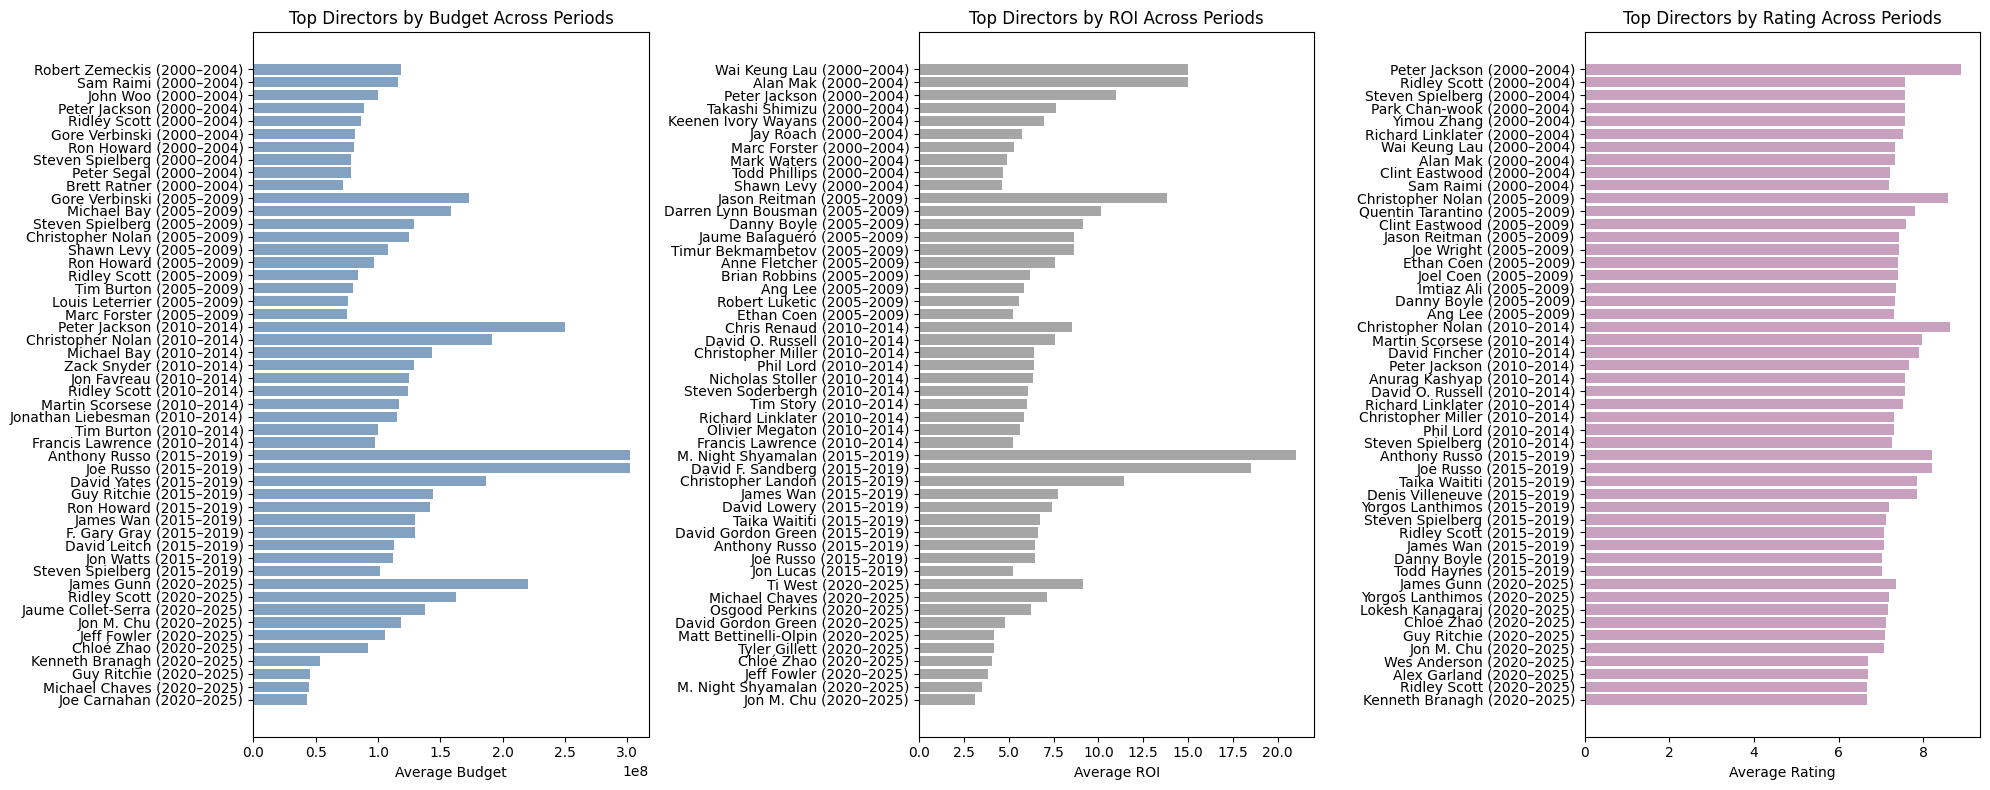

In [66]:
# DIRECTOR PERFORMANCE PLOTS


# split by type

budget_df = director_period_summary[director_period_summary["type"] == "Budget"]
roi_df = director_period_summary[director_period_summary["type"] == "ROI"]
rating_df = director_period_summary[director_period_summary["type"] == "Rating"]

# period order

periods = ["2000–2004", "2005–2009", "2010–2014", "2015–2019", "2020–2025"]

# colors (same as actors for consistency)

colors = {
    "Budget": "#4e79a7",   # blue
    "ROI": "gray",
    "Rating": "#b07aa1"    # purple
}

# CREATE 3 PLOTS

fig, axes = plt.subplots(1, 3, figsize=(20,8))



# BUDGET (DIRECTORS)

for period in periods:
    subset = budget_df[
        budget_df["period"] == period
    ].sort_values("value", ascending=False)

    axes[0].barh(
        subset["primaryName"] + " (" + period + ")",
        subset["value"],
        color=colors["Budget"],
        alpha=0.7
    )

axes[0].set_title("Top Directors by Budget Across Periods")
axes[0].set_xlabel("Average Budget")
axes[0].invert_yaxis()

# ROI (DIRECTORS)

for period in periods:
    subset = roi_df[
        roi_df["period"] == period
    ].sort_values("value", ascending=False)

    axes[1].barh(
        subset["primaryName"] + " (" + period + ")",
        subset["value"],
        color=colors["ROI"],
        alpha=0.7
    )

axes[1].set_title("Top Directors by ROI Across Periods")
axes[1].set_xlabel("Average ROI")
axes[1].invert_yaxis()

# RATING (DIRECTORS)

for period in periods:
    subset = rating_df[
        rating_df["period"] == period
    ].sort_values("value", ascending=False)

    axes[2].barh(
        subset["primaryName"] + " (" + period + ")",
        subset["value"],
        color=colors["Rating"],
        alpha=0.7
    )

axes[2].set_title("Top Directors by Rating Across Periods")
axes[2].set_xlabel("Average Rating")
axes[2].invert_yaxis()



plt.tight_layout()
plt.show()

## Director Performance Evolution Over Time

Analyzing director performance across 5-year periods reveals how the relationship between production scale (budget), financial efficiency (ROI), and audience reception (rating) evolves over time.

---

### 2000–2004: Strong Alignment Driven by Standout Projects

This period shows the clearest overlap across all three dimensions.

- Budget leaders (Robert Zemeckis, Sam Raimi, Peter Jackson, Ridley Scott) are associated with large-scale productions.
- Peter Jackson stands out by appearing in **all three rankings (budget, ROI, rating)**.
- Rating leaders (Jackson, Scott, Spielberg) strongly overlap with budget.
- ROI leaders include both high-impact directors (Jackson) and international/genre directors (Wai Keung Lau, Alan Mak).

**Key pattern:**  
A small number of standout films drive both financial success and ratings, creating strong alignment across all dimensions.

---

### 2005–2009: Clear Separation Emerges

The structure becomes more fragmented.

- Budget leaders (Gore Verbinski, Michael Bay, Spielberg) reflect **large-scale studio productions**, often franchise-related.
- ROI leaders (Jason Reitman, Danny Boyle) shift toward **efficient, mid-budget films**.
- Rating leaders (Christopher Nolan, Tarantino, Eastwood) are largely separate.

**Key pattern:**  
Budget, ROI, and rating diverge — each dimension is driven by different types of directors.

---

### 2010–2014: Scale Increases Without Convergence

Production scale expands significantly.

- Budget leaders (Peter Jackson, Christopher Nolan, Michael Bay) reflect blockbuster filmmaking.
- ROI leaders (Chris Renaud, David O. Russell, Lord & Miller) remain **efficiency-driven**.
- Rating leaders (Nolan, Scorsese, Fincher) represent **prestige cinema**.

**Key pattern:**  
Industry scale increases, but efficiency and critical success remain structurally separate.

---

### 2015–2019: Franchise Dominance with Partial Convergence

This period shows the strongest influence of franchise ecosystems.

- Budget leaders (Anthony Russo, Joe Russo, David Yates) are tightly linked to cinematic universes.
- The Russo brothers appear in **both budget and rating rankings**, indicating convergence.
- ROI leaders (M. Night Shyamalan, Sandberg, Landon) remain largely separate.

**Key pattern:**  
Blockbuster directors begin to achieve both scale and strong audience reception, but ROI remains independent.

---

### 2020–2025: Fragmentation and Mixed Models

The structure becomes more diversified and less dominated by a single pattern.

- Budget leaders (James Gunn, Ridley Scott, Jon M. Chu, Chloé Zhao) reflect a **mix of franchise films, studio projects, and standalone productions**.
- ROI leaders (Ti West, Michael Chaves, Osgood Perkins) are strongly concentrated in **horror/thriller**, reinforcing the efficiency model.
- Rating leaders (Yorgos Lanthimos, Chloé Zhao, Wes Anderson) reflect **director-driven and stylistic films**.

**Key pattern:**  
The industry becomes more diversified:

- Budget → mix of franchise and standalone productions  
- ROI → genre-driven (especially horror)  
- Rating → director-driven, stylistic films  

---

## Final Insight

Across all periods:

- Early 2000s → strong alignment driven by standout projects  
- Mid–late 2000s → clear structural separation  
- 2010s → increased scale without convergence  
- Late 2010s → partial convergence via franchises  
- 2020s → fragmentation and multiple coexisting models  

Overall:

- **Budget = scale and studio backing**  
- **ROI = efficiency and genre strategy**  
- **Rating = storytelling and directorial vision**

Director success remains **multi dimensional**, with only rare overlap across all three dimensions.

## Actor Star Power Clustering

While previous analysis examined actor performance across individual metrics such as ROI, rating, and budget, these dimensions capture only isolated aspects of success. In reality, actor performance is multi-dimensional, reflecting a combination of financial efficiency, production scale, audience reception, and popularity.

To better understand these interactions, we apply clustering to group actors into distinct archetypes based on multiple features simultaneously. Specifically, we incorporate:

- Financial performance (average ROI)  
- Audience reception (average rating)  
- Production scale (average budget)  
- Experience (number of movies)  
- Popularity (average votes)  

To ensure comparability across variables with different scales, we apply logarithmic transformations and standardization prior to clustering.

We then use K-Means clustering to identify underlying actor segments and evaluate the optimal number of clusters using both the Elbow Method and Silhouette Score.

In [67]:
import numpy as np

actor_stats_filtered = actor_stats_filtered.copy()

# Add log transformations

actor_stats_filtered["log_budget"] = np.log1p(actor_stats_filtered["avg_budget"])
actor_stats_filtered["log_movies"] = np.log1p(actor_stats_filtered["movies_count"])
actor_stats_filtered["log_votes"] = np.log1p(actor_stats_filtered["avg_votes"])

In [68]:
# Create feature matrix

X = actor_stats_filtered[[
    "avg_roi",
    "avg_rating",
    "log_budget",
    "log_movies",
    "log_votes"
]]

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

   ### Find optimal number of clusters

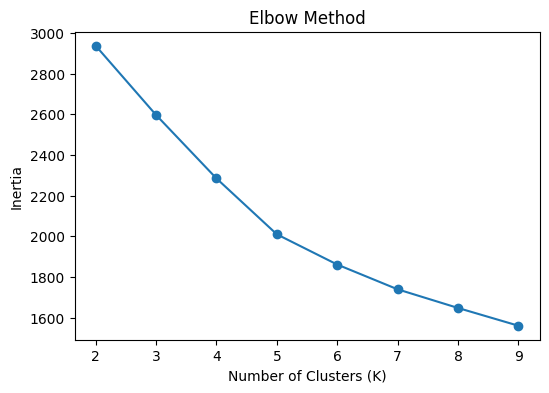

In [70]:
# Elbow method

from sklearn.cluster import KMeans


inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

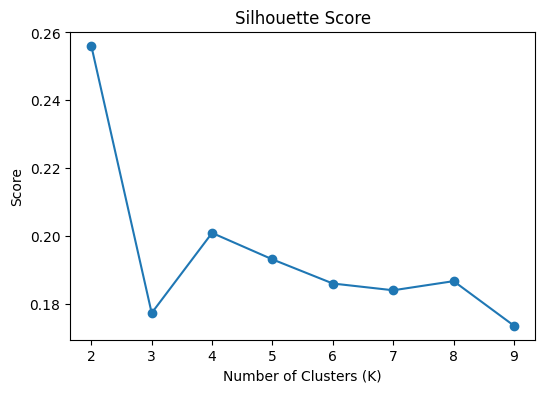

In [71]:
# Silhouette Score

from sklearn.metrics import silhouette_score

scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.show()

## Choice of Number of Clusters

The silhouette analysis indicates that the highest score is achieved at K = 2, suggesting that the data can be separated into two broad groups. However, this solution is overly simplistic and primarily captures a high-level split between high-profile actors and the rest.

Such a coarse segmentation fails to reflect the complexity of actor roles in the film industry, where performance depends on multiple interacting factors.

To capture this diversity, we select K = 4, which corresponds to the next-best silhouette score. This choice provides a more granular and interpretable segmentation, allowing us to distinguish between different actor archetypes such as:

- high-budget mainstream actors  
- prestige and highly visible actors  
- financially efficient actors  
- lower-impact actors  

In [72]:
# Fit final K-means model

kmeans = KMeans(n_clusters=4, random_state=42)

actor_stats_filtered["star_cluster"] = kmeans.fit_predict(X_scaled)

In [73]:
# Visualize with T-SNE

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_scaled)

actor_stats_filtered["tsne_1"] = X_tsne[:, 0]
actor_stats_filtered["tsne_2"] = X_tsne[:, 1]

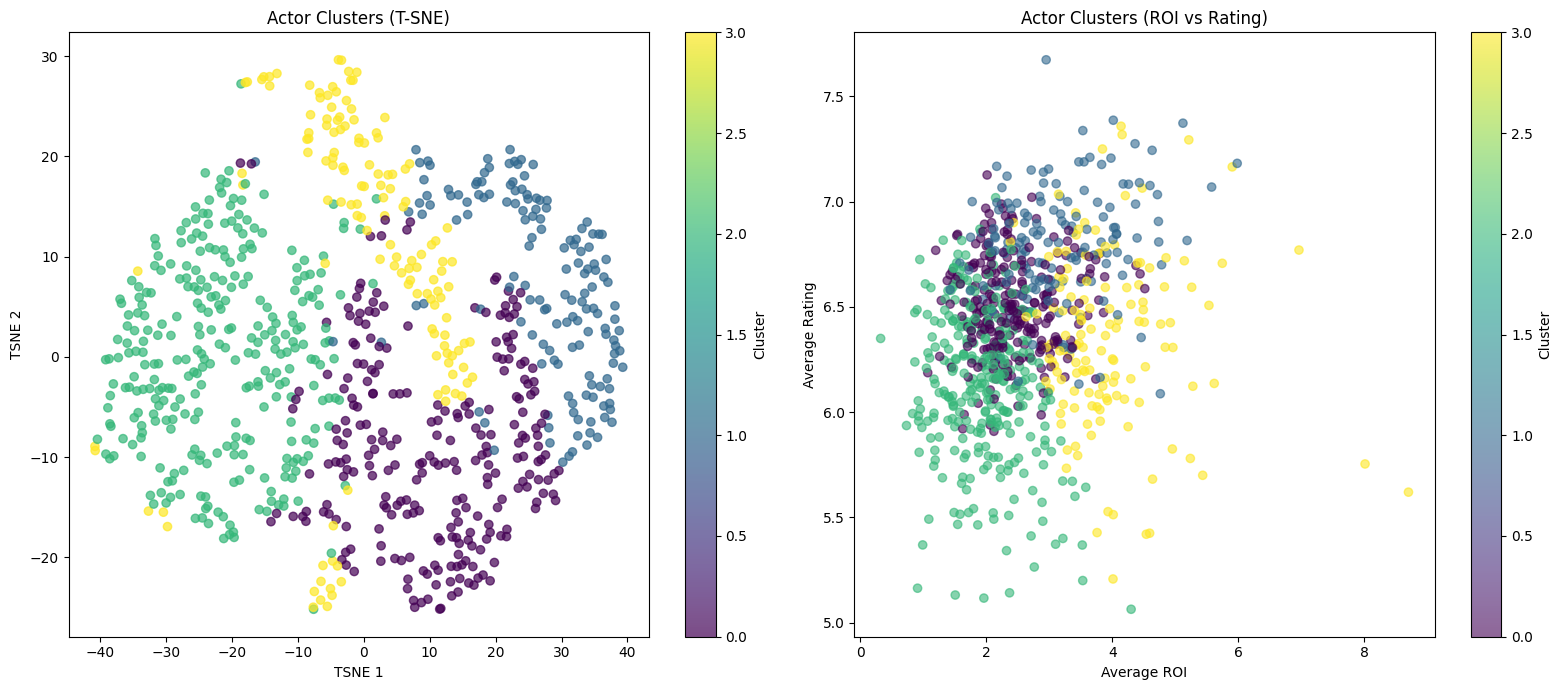

In [74]:
# Plot clusters (2 panel plot)

fig, axes = plt.subplots(1, 2, figsize=(16,7))

# LEFT: T-SNE

scatter1 = axes[0].scatter(
    actor_stats_filtered["tsne_1"],
    actor_stats_filtered["tsne_2"],
    c=actor_stats_filtered["star_cluster"],
    cmap="viridis",
    alpha=0.7
)

axes[0].set_title("Actor Clusters (T-SNE)")
axes[0].set_xlabel("TSNE 1")
axes[0].set_ylabel("TSNE 2")

fig.colorbar(scatter1, ax=axes[0], label="Cluster")



# RIGHT: REAL FEATURE SPACE

scatter2 = axes[1].scatter(
    actor_stats_filtered["avg_roi"],
    actor_stats_filtered["avg_rating"],
    c=actor_stats_filtered["star_cluster"],
    cmap="viridis",
    alpha=0.6
)

axes[1].set_title("Actor Clusters (ROI vs Rating)")
axes[1].set_xlabel("Average ROI")
axes[1].set_ylabel("Average Rating")

fig.colorbar(scatter2, ax=axes[1], label="Cluster")


plt.tight_layout()
plt.show()

In [75]:
# inspect cluster characteristics

actor_stats_filtered.groupby("star_cluster")[
    ["avg_roi","avg_rating","log_budget","log_movies", "log_votes"]
].mean().round(2)

,avg_roi,avg_rating,log_budget,log_movies,log_votes
star_cluster,,,,,
0,2.43,6.50,17.85,3.24,12.15
1,3.16,6.80,18.19,2.87,12.66
2,1.96,6.13,17.42,2.72,11.56
3,3.95,6.35,17.41,2.83,11.84


## Interpretation of Actor Star Power Clusters

The clustering results reveal distinct actor archetypes based on financial performance, production scale, audience reception, and popularity.

---

### Cluster 2 — Low-Impact Actors

Cluster 2 represents the weakest-performing group across all dimensions.

- Lowest ROI  
- Lowest ratings  
- Lowest budget, experience, and audience engagement  

These actors are associated with smaller productions that achieve limited commercial and critical success. This cluster reflects lower-impact or less established actors.

---

### Cluster 0 — High-Exposure Mainstream Actors

Cluster 0 is characterized by:

- High production budgets  
- High experience (movies count)  
- Moderate ROI and ratings  

These actors frequently appear in large-scale productions and maintain strong industry presence, but do not necessarily achieve the highest efficiency or critical acclaim.

This cluster represents mainstream actors embedded in large productions.

---

### Cluster 1 — Prestige & High-Visibility Actors

Cluster 1 stands out with:

- Highest ratings  
- Highest audience engagement (votes)  
- High budgets  

Although ROI is not the highest, these actors are associated with well-received and widely viewed films.

This cluster represents prestige or high-profile actors, combining strong audience reception with significant visibility.

---

### Cluster 3 — Financially Efficient Actors

Cluster 3 is defined by:

- Highest ROI  
- Moderate ratings  
- Lower budgets and popularity compared to Cluster 1  

These actors are associated with productions that generate strong financial returns relative to cost.

This cluster reflects financially efficient actors, often appearing in mid-budget or genre-driven films.

---

## Key Insight

Actor “star power” is multi-dimensional and cannot be captured by a single metric.

Three key dimensions emerge:

- **Scale (budget & exposure)**  
- **Audience perception (ratings & popularity)**  
- **Financial efficiency (ROI)**  

Importantly:

- High-budget actors are not the most efficient  
- High-ROI actors are not the most popular  
- High-rated actors are not necessarily tied to the largest productions  

While earlier analysis examined actor performance across individual metrics, clustering allows us to identify underlying actor archetypes by considering multiple dimensions simultaneously.

### Movie Clustering

While previous analysis focused on individual features such as budget, ROI, and ratings, these metrics capture only isolated aspects of movie performance. In reality, movies are characterized by a combination of financial, production, and audience related factors.

To better understand these interactions, we apply clustering to group movies into distinct types based on multiple features simultaneously. This allows us to identify underlying movie archetypes, such as high budget blockbusters, financially efficient films, or critically successful productions.

Unlike ranking based analysis, clustering provides a structured view of how movies differ across several dimensions at once. These clusters can then be used both for deeper interpretation of industry patterns and as additional features in predictive models for revenue and success.

In [76]:
movies["log_budget"] = np.log1p(movies["budget"])
movies["log_votes"] = np.log1p(movies["numVotes"])
movies["log_runtime"] = np.log1p(movies["runtime"])

In [77]:
# Feature set

X_movies = movies[[
    "roi",
    "rating",
    "log_budget",
    "log_votes",
    "log_runtime"
]]

In [78]:
# Scale

scaler = StandardScaler()
X_movies_scaled = scaler.fit_transform(X_movies)

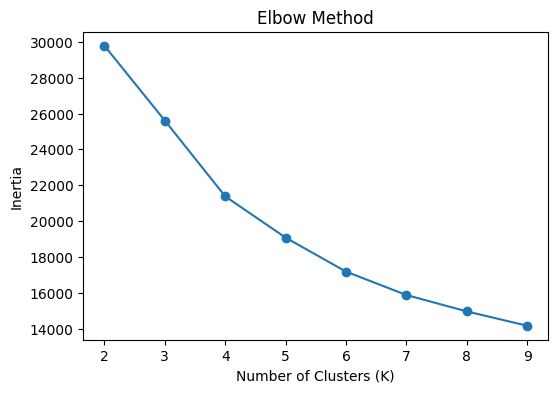

In [79]:
# Elbow method for movies


inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_movies_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

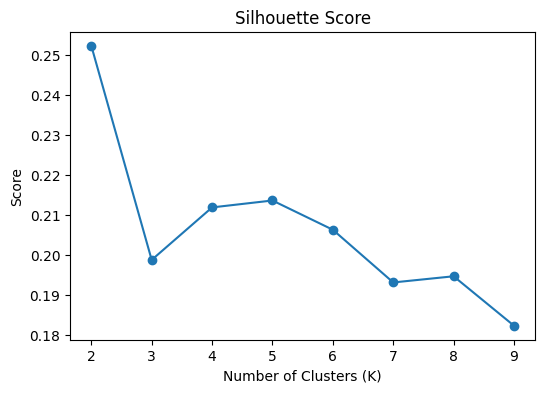

In [80]:
# Silhouette Score for movies

from sklearn.metrics import silhouette_score

scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_movies_scaled)
    scores.append(silhouette_score(X_movies_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.show()

### Choice of Number of Clusters

The silhouette analysis indicates that the highest score is achieved at **K = 2**, suggesting that movies can be separated into two broad groups. However, this solution is overly simplistic and primarily captures a high-level split (e.g., high-performing vs. lower-performing films), which limits interpretability.

In practice, movie performance is multi-dimensional and driven by several interacting factors, including budget, financial efficiency (ROI), audience reception (ratings), and popularity (votes). A two-cluster solution fails to capture this diversity and does not reflect the variety of movie types observed in the industry.

To obtain a more meaningful segmentation, we select **K = 5**, which corresponds to the next-best silhouette score. This choice allows us to identify a richer set of movie archetypes, such as:

- high-budget blockbuster films  
- financially efficient (high-ROI) productions  
- critically successful (high-rating) films  
- mainstream mid-tier movies  
- lower-performing or niche films  

Although the silhouette score is slightly lower than for K = 2, the **K = 5 solution provides significantly greater interpretability and aligns better with domain knowledge** about the structure of the film industry.



In [81]:
# Fit K-Means

kmeans_movies = KMeans(n_clusters=5, random_state=42)

movies["movie_cluster"] = kmeans_movies.fit_predict(X_movies_scaled)

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_movies_scaled)

movies["tsne_1"] = X_tsne[:, 0]
movies["tsne_2"] = X_tsne[:, 1]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

# LEFT: T-SNE (structure)

scatter1 = axes[0].scatter(
    movies["tsne_1"],
    movies["tsne_2"],
    c=movies["movie_cluster"],
    cmap="viridis",
    alpha=0.6
)

axes[0].set_title("Movie Clusters (T-SNE)")
axes[0].set_xlabel("TSNE 1")
axes[0].set_ylabel("TSNE 2")

fig.colorbar(scatter1, ax=axes[0], label="Cluster")


# RIGHT: REAL FEATURE SPACE

scatter2 = axes[1].scatter(
    movies["budget"],
    movies["rating"],
    c=movies["movie_cluster"],
    cmap="viridis",
    alpha=0.6
)

axes[1].set_xscale("log")

axes[1].set_title("Movie Clusters (Budget vs Rating)")
axes[1].set_xlabel("Budget (log scale)")
axes[1].set_ylabel("Rating")

fig.colorbar(scatter2, ax=axes[1], label="Cluster")


plt.tight_layout()
plt.show()

In [ ]:
# inspect cluster characteristics

movies.groupby("movie_cluster")[
    ["roi","rating","log_budget","log_votes", "log_runtime"]
].mean().round(2)

## Interpretation of Movie Clusters

The clustering results reveal distinct types of movies characterized by differences in financial performance, production scale, audience reception, and popularity.

---

### Cluster 1 — Low-Budget, Low-Impact Films

- Lowest budgets and popularity  
- Lowest ratings  
- Low ROI  

These films represent small-scale productions with limited reach and modest performance.

---

### Cluster 2 — Moderate-to-High Budget, Underperforming Films

- Relatively high budgets  
- Low ROI and lower ratings  

These films reflect inefficient productions where high investment does not translate into strong outcomes.

---

### Cluster 3 — Mid-Tier Mainstream Films

- Moderate budgets and popularity  
- Solid ratings  
- Average ROI  

These films represent stable, mainstream productions that perform consistently without excelling in any single dimension.

---

### Cluster 0 — Balanced High-Performing Films

- Strong ROI  
- High ratings  
- Solid popularity  
- Moderate budgets  

These films successfully balance financial performance and audience reception.

---

### Cluster 4 — Highly Efficient Films

- Exceptionally high ROI  
- Moderate budgets  
- Good ratings and popularity  

These films achieve outstanding financial efficiency, generating strong returns relative to their cost.

---

## Key Insight

Movie performance is inherently multi-dimensional and driven by trade-offs between:

- Financial efficiency (ROI)  
- Production scale (budget)  
- Audience reception (rating)  
- Popularity (votes)  

Importantly:

- High budgets do not guarantee success  
- The most efficient films are not necessarily the largest  
- Strong performance often comes from balancing multiple factors  

# Role of Clustering in the Analysis

The clustering approach in this project serves two complementary purposes.

First, it provides an exploratory perspective by identifying underlying structures in the data. By grouping actors and movies based on multiple dimensions (financial performance, production scale, audience reception, and popularity), we uncover distinct archetypes that cannot be observed through single variable analysis alone.

Second, clustering can be viewed as a form of feature engineering. The resulting cluster labels represent higher-level summaries of complex characteristics and can be incorporated into predictive models. For example, movie or actor cluster membership could be used as an additional feature in:

- classification tasks (e.g., predicting movie success)  
- regression models (e.g., predicting revenue or ROI)

However, the primary objective of clustering in this analysis is **interpretability rather than prediction**. The clusters help explain how different types of actors and movies behave within the industry, while their use in modeling remains an optional extension for future work.